```
pip install 'pandas[pyarrow]'
pip install "chronos-forecasting>=2.0"
pip install matplotlib
pip install numpy
pip install scikit-learn
pip install yfinance
pip install fredapi


# Zero-Shot


### HF Test

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline


# Use CPU because Torch is not compiled with CUDA on this environment
#pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

In [2]:
# Load historical target values and past values of covariates
context_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet")
print(context_df.head())

   id           timestamp     target  Ampirion Load Forecast  PV+Wind Forecast
0  DE 2012-01-09 00:00:00  34.970001                16382.00       3569.527588
1  DE 2012-01-09 01:00:00  33.430000                15410.50       3315.274902
2  DE 2012-01-09 02:00:00  32.740002                15595.00       3107.307617
3  DE 2012-01-09 03:00:00  32.459999                16521.00       2944.620117
4  DE 2012-01-09 04:00:00  32.500000                17700.75       2897.149902


In [3]:
# (Optional) Load future values of covariates
test_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet")
future_df = test_df.drop(columns="target")
print(future_df.head())

   id           timestamp  Ampirion Load Forecast  PV+Wind Forecast
0  DE 2017-12-12 00:00:00                20483.00      22284.005859
1  DE 2017-12-12 01:00:00                19849.75      22878.673828
2  DE 2017-12-12 02:00:00                19638.25      23632.283203
3  DE 2017-12-12 03:00:00                19895.25      24635.945312
4  DE 2017-12-12 04:00:00                20338.00      25584.935547


In [7]:
# Generate predictions with covariates
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantiles for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)

c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


### Zero-Shot with volatility


In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline

In [ ]:
# read csv
df = pd.read_csv("UBS.csv")

# format csv
df.columns = df.columns.str.lower()

# convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.sort_values("timestamp", inplace=True)

# Add Business Day index
all_bdays = pd.date_range(start=df["timestamp"].min(), end=df["timestamp"].max(), freq='B')

# reindex to business days
df = df.set_index("timestamp").reindex(all_bdays)
df.index.name = "timestamp"
df = df.reset_index()

# forward fill missing values
cols_price = ["open", "high", "low", "close", "volume", "sma", "ema", "rsi", "atr", "real lower band", "real middle band", "real upper band", "macd", "macd signal", "macd hist"]
for col in cols_price:
    if col in df.columns:
        df[col] = df[col].ffill()

# add volatility and lagged volatility
df["hl_vol"] = np.log(df["high"]/df["low"])
df["hl_vol_lag1"] = df["hl_vol"].shift(1)
df = df.dropna(subset=["hl_vol_lag1"]).reset_index(drop=True)

#Single-ID für chronos
df["id"] = "UBS"

print(len(df))
print(df.head())

2829
   timestamp   open    high    low  close     volume      sma      ema  \
0 2015-01-13  16.65  16.825  16.46  16.59  1722594.0  11.6180  11.6630   
1 2015-01-14  16.54  16.580  16.26  16.48  2195439.0  11.6262  11.6375   
2 2015-01-15  16.90  16.980  16.17  16.53  9113910.0  11.6075  11.6292   
3 2015-01-16  16.02  16.380  16.01  16.23  2733547.0  11.5583  11.5632   
4 2015-01-19  16.02  16.380  16.01  16.23  2733547.0  11.5583  11.5632   

       rsi     atr  real lower band  real middle band  real upper band  \
0  44.8909  0.3137          11.3996           11.9963          12.5931   
1  43.7858  0.3079          11.3485           11.9717          12.5950   
2  44.4551  0.3265          11.3076           11.9475          12.5875   
3  41.2790  0.3293          11.2360           11.9075          12.5790   
4  41.2790  0.3293          11.2360           11.9075          12.5790   

     macd  macd_hist  macd_signal    hl_vol  hl_vol_lag1      id  
0 -0.3262    -0.0003      -0.3259  0.0

In [106]:
# Train / Test split: last 20 days as forecast horizon

prediction_length = 80

context_df = df.iloc[:-prediction_length].copy()
test_df = df.iloc[-prediction_length:].copy()
print("---------------")
print("Context DF")
print(len(context_df))
print(context_df.head())
print("---------------")
print("Test DF")
print(len(test_df))
print(test_df.head())

# Chronos expects:
# - context_df: id, timestamp, target, maybe covariates
# - future_df: id, timestamp, only covariates (no target)

context_df_chronos = context_df[["id", "timestamp", "hl_vol", "hl_vol_lag1"]].copy()
future_df_chronos  = test_df[["id", "timestamp", "hl_vol_lag1"]].copy()
print("---------------")
print("Context DF Chronos")
print(len(context_df_chronos))
print(context_df_chronos.head())
print("---------------")
print("Future DF Chronos")
print(len(future_df_chronos))
print(future_df_chronos.head())


---------------
Context DF
2749
   timestamp   open    high    low  close     volume      sma      ema  \
0 2015-01-13  16.65  16.825  16.46  16.59  1722594.0  11.6180  11.6630   
1 2015-01-14  16.54  16.580  16.26  16.48  2195439.0  11.6262  11.6375   
2 2015-01-15  16.90  16.980  16.17  16.53  9113910.0  11.6075  11.6292   
3 2015-01-16  16.02  16.380  16.01  16.23  2733547.0  11.5583  11.5632   
4 2015-01-19  16.02  16.380  16.01  16.23  2733547.0  11.5583  11.5632   

       rsi     atr  real lower band  real middle band  real upper band  \
0  44.8909  0.3137          11.3996           11.9963          12.5931   
1  43.7858  0.3079          11.3485           11.9717          12.5950   
2  44.4551  0.3265          11.3076           11.9475          12.5875   
3  41.2790  0.3293          11.2360           11.9075          12.5790   
4  41.2790  0.3293          11.2360           11.9075          12.5790   

     macd  macd_hist  macd_signal    hl_vol  hl_vol_lag1      id  
0 -0.3262  

In [107]:
# Load Chronos2
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

# Predict last 20 days
pred_df = pipeline.predict_df(
    context_df_chronos,
    future_df_chronos,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="hl_vol",
)

c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [108]:
# Merge predictions with real values
results = pred_df.merge(
    test_df[["id", "timestamp", "hl_vol"]],
    on=["id", "timestamp"],
    how="left",
)

print(results.head())


       id  timestamp target_name  predictions       0.1       0.5       0.9  \
0  nestle 2025-07-28      hl_vol     0.006535  0.005056  0.006535  0.008026   
1  nestle 2025-07-29      hl_vol     0.010895  0.008925  0.010895  0.012927   
2  nestle 2025-07-30      hl_vol     0.012890  0.010592  0.012890  0.015156   
3  nestle 2025-07-31      hl_vol     0.009990  0.008202  0.009990  0.012129   
4  nestle 2025-08-01      hl_vol     0.023626  0.021377  0.023626  0.026055   

     hl_vol  
0  0.005943  
1  0.011072  
2  0.014069  
3  0.009631  
4  0.023511  


In [109]:
#  Calculate prediction quality (based on median q_0.5)
y_true = results["hl_vol"]    
y_pred = results["0.5"] 

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred)**0.5

print("MAE  (hl_vol):", mae)
print("RMSE (hl_vol):", rmse)

MAE  (hl_vol): 0.0009818340845692715
RMSE (hl_vol): 0.0013114838856833225


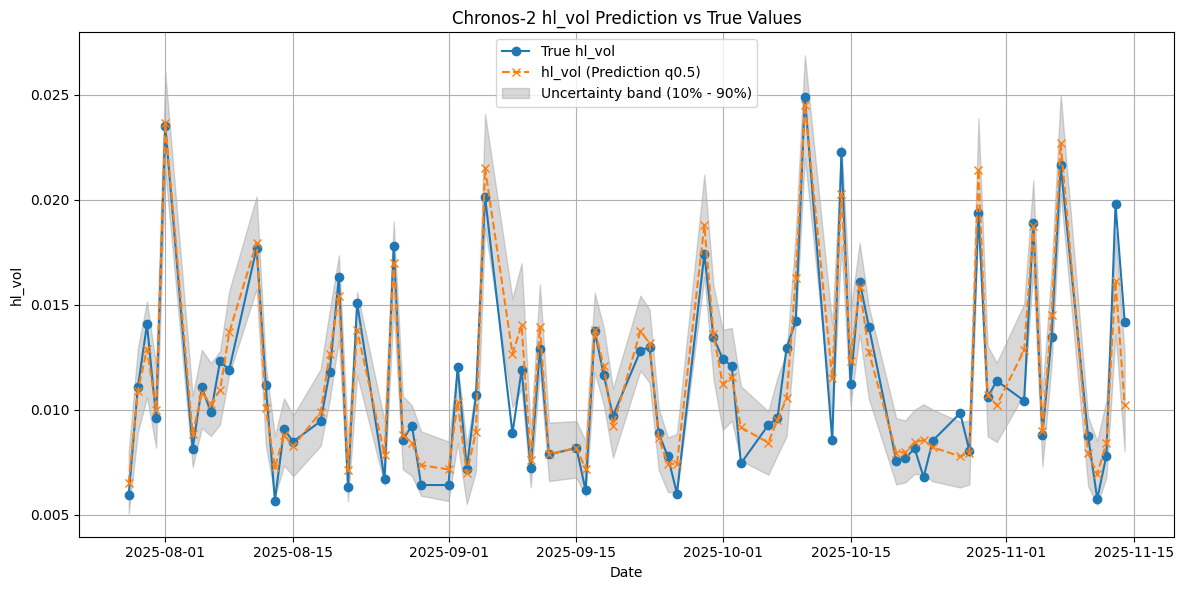

In [ ]:
# Plot predictions vs true values

plt.figure(figsize=(12, 6))

plt.plot(results["timestamp"], y_true, marker='o', label='True hl_vol')
plt.plot(results["timestamp"], y_pred, marker="x", linestyle="--", label="hl_vol (Prediction q0.5)")

# Uncertainty bands 10% - 90%
plt.fill_between(
    results["timestamp"],
    results["0.1"],
    results["0.9"],
    color="gray",
    alpha=0.3,
    label="Uncertainty band (10% - 90%)",
)

plt.title("Chronos-2 hl_vol Prediction vs True Values")
plt.xlabel("Date")
plt.ylabel("hl_vol")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Engineering

In [ ]:
import numpy as np
import pandas as pd



In [138]:
# read csv
df = pd.read_csv("UBS.csv")

# format csv
df.columns = df.columns.str.lower()

# convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.sort_values("timestamp", inplace=True)

# Add Business Day index
all_bdays = pd.date_range(start=df["timestamp"].min(), end=df["timestamp"].max(), freq='B')

# reindex to business days
df = df.set_index("timestamp").reindex(all_bdays)
df.index.name = "timestamp"
df = df.reset_index()

# forward fill missing values
cols_price = ["open", "high", "low", "close", "volume", "sma", "ema", "rsi", "atr", "real lower band", "real middle band", "real upper band", "macd", "macd_signal", "macd_hist"]
for col in cols_price:
    if col in df.columns:
        df[col] = df[col].ffill()

# add volatility and lagged features
df["hl_vol"] = np.log(df["high"]/df["low"])
df["hl_vol_lag1"] = df["hl_vol"].shift(1)
df["sma_lag1"] = df["sma"].shift(1)
df["ema_lag1"] = df["ema"].shift(1)
df["rsi_lag1"] = df["rsi"].shift(1)
df["atr_lag1"] = df["atr"].shift(1)
df["bb_lower_lag1"] = df["real lower band"].shift(1)
df["bb_mid_lag1"]   = df["real middle band"].shift(1)
df["bb_upper_lag1"] = df["real upper band"].shift(1)
df["macd_lag1"] = df["macd"].shift(1)
df["macd_hist_lag1"] = df["macd_hist"].shift(1)
df["macd_signal_lag1"] = df["macd_signal"].shift(1)


# add Bollinger-Band width and lagged version
df["bb_width"] = (df["real upper band"] - df["real lower band"]) / df["real middle band"]
df["bb_width_lag1"] = df["bb_width"].shift(1)

# drop rows with NaN in lagged features
df = df.dropna(
    subset=[
        "hl_vol_lag1",
        "sma_lag1", "ema_lag1", "rsi_lag1", "atr_lag1",
        "bb_lower_lag1", "bb_mid_lag1", "bb_upper_lag1",
        "macd_lag1", "macd_hist_lag1", "macd_signal_lag1",
        "bb_width_lag1"
    ])

#Single-ID für chronos
df["id"] = "UBS"

print(len(df))
df.head()

2829


,timestamp,open,high,low,close,volume,sma,ema,rsi,atr,...,atr_lag1,bb_lower_lag1,bb_mid_lag1,bb_upper_lag1,macd_lag1,macd_hist_lag1,macd_signal_lag1,bb_width,bb_width_lag1,id
1,2015-01-13,16.65,16.825,16.46,16.59,1722594.0,11.6180,11.6630,44.8909,0.3137,...,0.3138,11.4426,12.0248,12.6070,-0.3382,-0.0124,-0.3258,0.099489,0.096833,UBS
2,2015-01-14,16.54,16.580,16.26,16.48,2195439.0,11.6262,11.6375,43.7858,0.3079,...,0.3137,11.3996,11.9963,12.5931,-0.3262,-0.0003,-0.3259,0.104121,0.099489,UBS
3,2015-01-15,16.90,16.980,16.17,16.53,9113910.0,11.6075,11.6292,44.4551,0.3265,...,0.3079,11.3485,11.9717,12.5950,-0.3192,0.0054,-0.3245,0.107127,0.104121,UBS
4,2015-01-16,16.02,16.380,16.01,16.23,2733547.0,11.5583,11.5632,41.2790,0.3293,...,0.3265,11.3076,11.9475,12.5875,-0.3072,0.0138,-0.3211,0.112786,0.107127,UBS
5,2015-01-19,16.02,16.380,16.01,16.23,2733547.0,11.5583,11.5632,41.2790,0.3293,...,0.3293,11.2360,11.9075,12.5790,-0.3112,0.0079,-0.3191,0.112786,0.112786,UBS


In [170]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from IPython.display import display

prediction_length = 100
experiments = {}

def run_experiment(name, feature_cols, df_source, prediction_length=100):
    """
    name = name of experiment
    feature_cols = list of feature columns to use
    df_source: dataframe with id, timesampt, hl_vol and all features
    """

    # Prepare data: drop rows with NaN in target or features
    cols_needed = ["hl_vol"] + feature_cols
    df_local = df_source.dropna(subset=cols_needed).copy()

    # Train / Test-split
    context_df = df_local.iloc[:-prediction_length].copy()
    test_df = df_local.iloc[-prediction_length:].copy()

    # Build Chronos input
    context_cols = ["id", "timestamp", "hl_vol"] + feature_cols
    future_cols = ["id", "timestamp"] + feature_cols

    context_df_chronos = context_df[context_cols].reset_index(drop=True)
    future_df_chronos  = test_df[future_cols].reset_index(drop=True)

    # Predict with Chronos-2
    pred_df = pipeline.predict_df(
        context_df_chronos,
        future_df=future_df_chronos,
        prediction_length=prediction_length,
        quantile_levels=[0.1, 0.5, 0.9],
        id_column="id",
        timestamp_column="timestamp",
        target="hl_vol",
    )

    # Merge predictions with real values
    results = pred_df.merge(
        test_df[["id", "timestamp", "hl_vol"]],
        on=["id", "timestamp"],
        how="left",
    )

    y_true = results["hl_vol"]
    y_pred = results["0.5"]


    # Calculate metrics
    # Directional Accuracy
    true_diff = y_true.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    pred_diff = y_pred.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    directional_accuracy = (true_diff == pred_diff).mean()

    #mae + rmse
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5

    # Spearman/Person Correlation
    pearson_corr = y_true.corr(y_pred, method="pearson")
    spearman_corr = y_true.corr(y_pred, method="spearman")

    experiments[name] = {
        "feature_cols": feature_cols,
        "results": results,
        "y_true": y_true,
        "y_pred": y_pred,
        "mae": mae,
        "rmse": rmse,
        "directional_accuracy": directional_accuracy,
        "pearson": pearson_corr,
        "spearman": spearman_corr,
    }

    print(f"Experiment: {name}: MAE={mae:.6f}, RMSE={rmse:.6f}, DirAcc={directional_accuracy}, Pearson={pearson_corr}, Spearman={spearman_corr}")



In [171]:
# Define experiments with different feature sets and run them

# 1) Baseline: only hl_vol_lag1
run_experiment(
    name="baseline_hl_vol_lag1",
    feature_cols=["hl_vol_lag1"],
    df_source=df,
)

# 2) Trend-Focus: hl_vol_lag1 + SMA/EMA
#run_experiment(
#    name="trend_lags",
#    feature_cols=["hl_vol_lag1", "sma_lag1", "ema_lag1"],
#    df_source=df,
#)

# 3) Momentum-Focus: hl_vol_lag1 + RSI + MACD
run_experiment(
    name="momentum_lags",
    feature_cols=["hl_vol_lag1", "rsi_lag1",
                  "macd_lag1", "macd_signal_lag1", "macd_hist_lag1"],
    df_source=df,
)

#4) Volatility / Band Focus: hl_vol_lag1 + ATR + Bollinger
#run_experiment(
#    name="vola_bands_lags",
#    feature_cols=[
#        "hl_vol_lag1",
#        "atr_lag1",
#        "bb_lower_lag1", "bb_mid_lag1", "bb_upper_lag1", "bb_width_lag1",
#    ],
#    df_source=df,
#)

# 5) Volatility with only MACD
run_experiment(
    name="vola_macd_lags",
    feature_cols=["hl_vol_lag1",
        "macd_lag1", "macd_signal_lag1", "macd_hist_lag1"],
    df_source=df,
)



c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Experiment: baseline_hl_vol_lag1: MAE=0.001072, RMSE=0.001378, DirAcc=0.82, Pearson=0.948846370070337, Spearman=0.9362852462529577


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Experiment: momentum_lags: MAE=0.001016, RMSE=0.001326, DirAcc=0.84, Pearson=0.9504102542022536, Spearman=0.9289044638898943


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Experiment: vola_macd_lags: MAE=0.000986, RMSE=0.001303, DirAcc=0.83, Pearson=0.9531175135036359, Spearman=0.9331649154978415


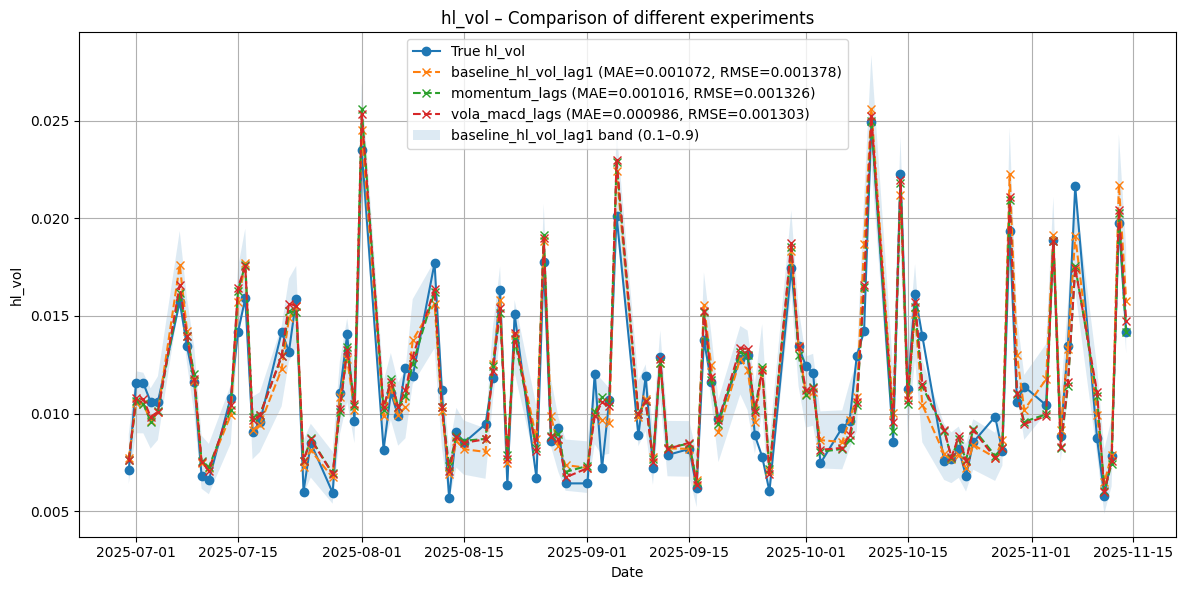

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_hl_vol_lag1,0.001072,0.001378,0.82,0.948846,0.936285
momentum_lags,0.001016,0.001326,0.84,0.950410,0.928904
vola_macd_lags,0.000986,0.001303,0.83,0.953118,0.933165


In [172]:
# Comparison plot & metrcis table

def plot_experiments(experiments_dict):
    if not experiments_dict:
        print("No experiments to plot.")
        return
    
    plt.figure(figsize=(12, 6))

    # Reference for real values and uncertainty bands
    first_key = next(iter(experiments_dict))
    base_res = experiments_dict[first_key]["results"]
    timestamps = base_res["timestamp"]

    # True hl_vol
    plt.plot(
        timestamps,
        base_res["hl_vol"],
        marker="o",
        label="True hl_vol",
    )

    # Each experiment as line
    for name, exp in experiments_dict.items():
        res = exp["results"]
        plt.plot(
            res["timestamp"],
            exp["y_pred"],
            marker="x",
            linestyle="--",
            label=f"{name} (MAE={exp['mae']:.6f}, RMSE={exp['rmse']:.6f})",
        )

    # Uncertainty band of reference
    plt.fill_between(
        base_res["timestamp"],
        base_res["0.1"],
        base_res["0.9"],
        alpha=0.15,
        label=f"{first_key} band (0.1–0.9)",
    )

    plt.title("hl_vol – Comparison of different experiments")
    plt.xlabel("Date")
    plt.ylabel("hl_vol")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Metris Table
    metrics_df = pd.DataFrame(
    [
        {"Variant": name,
         "MAE": exp["mae"],
         "RMSE": exp["rmse"],
         "DirAcc": exp["directional_accuracy"],
         "Pearson": exp["pearson"],
         "Spearman": exp["spearman"]
        }
        for name, exp in experiments_dict.items()
    ]
    
).set_index("Variant")

    display(metrics_df)


# Show plot and metrics table
plot_experiments(experiments)


# Feature Engineering Part II
Data leakage is in the previous example possible. 
Therefore we perform a Rolling 1-Day-Ahead Backtest.
For each day in the backtest window, I use **only data up to yesterday** 
and let Chronos-2 forecast exactly **one day** into the future.
This gives me a clean 1-day-ahead evaluation (without lookahead leakage).

In [198]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from IPython.display import display

In [199]:
# Amount of Days we rollback
backtest_length = 10

In [200]:
# Previously defined Feature sets. But for Rolling-Backtest.
rolling_feature_sets = {
    "baseline_hl_vol_lag1": ["hl_vol_lag1"],
    #"momentum_lags": ["hl_vol_lag1", "rsi_lag1", "macd_lag1", "macd_signal_lag1", "macd_hist_lag1"],
    #"vola_macd_lags": ["hl_vol_lag1", "macd_lag1", "macd_signal_lag1", "macd_hist_lag1"],
    "vola_bands_lags": ["hl_vol_lag1", "atr_lag1", "bb_lower_lag1", "bb_mid_lag1", "bb_upper_lag1", "bb_width_lag1"],
}


rolling_experiments = {}

In [201]:
def run_rolling_backtest(name, feature_cols, df_source, backtest_length=10):
    """
    name: Name des Experiments (z.B. 'vola_macd_lags')
    feature_cols: Liste der verwendeten Feature-Spalten
    df_source: DataFrame mit 'id', 'timestamp', 'hl_vol' und Features
    backtest_length: Anzahl der Tage für den Rolling-Backtest (vom Ende der Serie rückwärts)
    """

    cols_needed = ["hl_vol"] + feature_cols
    df_local = df_source.dropna(subset=cols_needed).copy()
    df_local = df_local.sort_values("timestamp").reset_index(drop=True)

    n = len(df_local)
    if backtest_length >= n:
        raise ValueError(f"backtest_length={backtest_length} ist zu groß für n={n}")

    # Indizes der Tage, die wir evaluieren (immer 1-Day-Ahead)
    eval_indices = list(range(n - backtest_length, n))

    records = []  # hier landen alle Einzeltage: true, pred, quantile, timestamp

    for idx in eval_indices:
        # Kontext: alle Daten BIS VOR den aktuellen Tag
        context_df = df_local.iloc[:idx].copy()
        future_row = df_local.iloc[idx]  # Series, der "heutige" Tag, den wir vorhersagen wollen

        if len(context_df) == 0:
            continue  # nur zur Sicherheit

        # Kontext für Chronos: Target + Features bis gestern
        context_cols = ["id", "timestamp", "hl_vol"] + feature_cols
        context_df_chronos = context_df[context_cols].reset_index(drop=True)

        # 1-Day-Ahead Forecast OHNE future_df
        pred_df = pipeline.predict_df(
            context_df_chronos,
            prediction_length=1,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="id",
            timestamp_column="timestamp",
            target="hl_vol",
        )

        # Es kommt genau eine Zeile zurück
        pred_ts = pred_df["timestamp"].iloc[0]
        q01 = pred_df["0.1"].iloc[0]
        q05 = pred_df["0.5"].iloc[0]
        q09 = pred_df["0.9"].iloc[0]

        true_ts = future_row["timestamp"]
        true_val = future_row["hl_vol"]

        # Sicherstellen, dass der prognostizierte Zeitpunkt = tatsächlichem Tag entspricht
        # (da wir BusinessDay-Frequenz haben, sollte das passen)
        # Optional:
        # assert pred_ts == true_ts

        records.append(
            {
                "timestamp": true_ts,
                "y_true": true_val,
                "y_pred": q05,
                "q_0.1": q01,
                "q_0.5": q05,
                "q_0.9": q09,
            }
        )

    results_df = pd.DataFrame(records).sort_values("timestamp").reset_index(drop=True)

    # Metriken berechnen (über alle Backtest-Tage)
    y_true = results_df["y_true"]
    y_pred = results_df["y_pred"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5

    # Directional Accuracy
    true_diff = y_true.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    pred_diff = y_pred.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    directional_accuracy = (true_diff == pred_diff).mean()

    # Korrelationen
    pearson_corr = y_true.corr(y_pred, method="pearson")
    spearman_corr = y_true.corr(y_pred, method="spearman")

    rolling_experiments[name] = {
        "feature_cols": feature_cols,
        "results": results_df,
        "y_true": y_true,
        "y_pred": y_pred,
        "mae": mae,
        "rmse": rmse,
        "directional_accuracy": directional_accuracy,
        "pearson": pearson_corr,
        "spearman": spearman_corr,
    }

    print(
        f"{name}: MAE={mae:.6f}, RMSE={rmse:.6f}, "
        f"DirAcc={directional_accuracy:.3f}, "
        f"Pearson={pearson_corr:.3f}, Spearman={spearman_corr:.3f}"
    )


In [202]:
for name, feat_cols in rolling_feature_sets.items():
    run_rolling_backtest(
        name=name,
        feature_cols=feat_cols,
        df_source=df,
        backtest_length=backtest_length,
    )

c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

baseline_hl_vol_lag1: MAE=0.004934, RMSE=0.005959, DirAcc=0.200, Pearson=-0.279, Spearman=-0.261


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

vola_bands_lags: MAE=0.004862, RMSE=0.005889, DirAcc=0.200, Pearson=-0.290, Spearman=-0.115


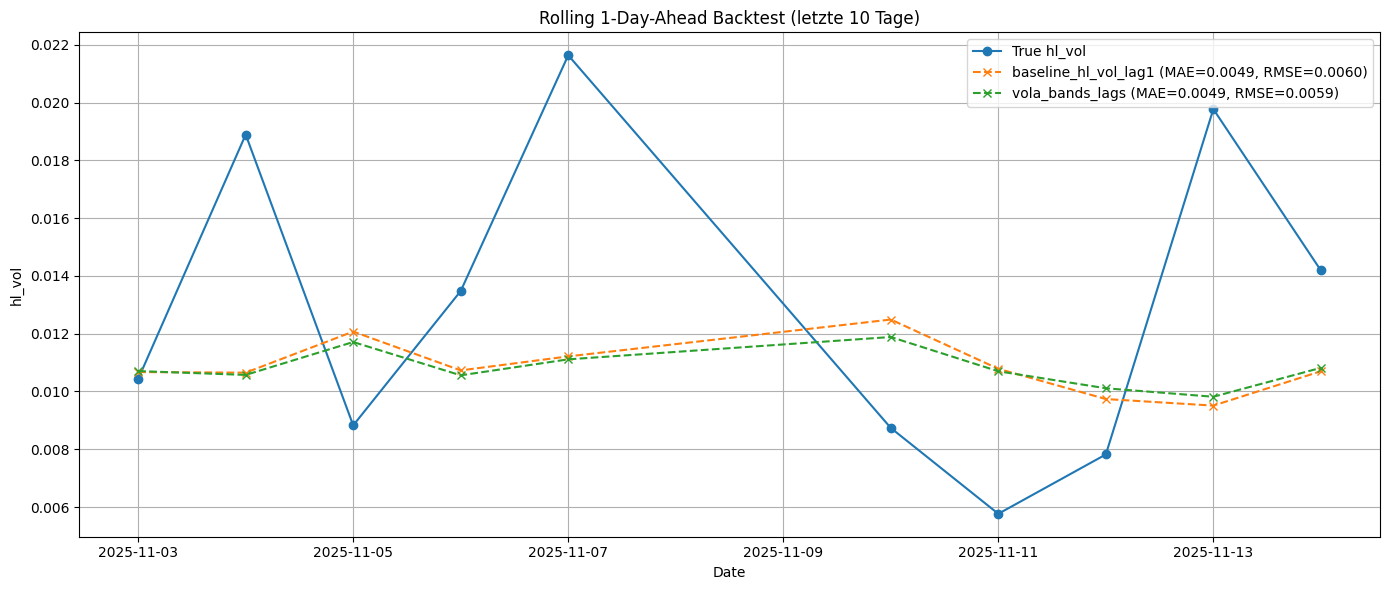

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_hl_vol_lag1,0.004934,0.005959,0.2,-0.279402,-0.260606
vola_bands_lags,0.004862,0.005889,0.2,-0.290183,-0.115152


In [203]:
def plot_rolling_experiments(rolling_experiments_dict):
    if not rolling_experiments_dict:
        print("No rolling-experiments available")
        return
    
    plt.figure(figsize=(14, 6))

    # Reference: True values
    first_key = next(iter(rolling_experiments_dict))
    base_res = rolling_experiments_dict[first_key]["results"]

    plt.plot(
        base_res["timestamp"],
        base_res["y_true"],
        marker="o",
        label="True hl_vol",
    )

    # variantes
    # Varianten einzeichnen
    for name, exp in rolling_experiments_dict.items():
        res = exp["results"]
        plt.plot(
            res["timestamp"],
            res["y_pred"],
            linestyle="--",
            marker="x",
            label=f"{name} (MAE={exp['mae']:.4f}, RMSE={exp['rmse']:.4f})",
        )

    plt.title(f"Rolling 1-Day-Ahead Backtest (letzte {backtest_length} Tage)")
    plt.xlabel("Date")
    plt.ylabel("hl_vol")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Metric table
    metrics_df = pd.DataFrame(
        [
            {
                "Variant": name,
                "MAE": exp["mae"],
                "RMSE": exp["rmse"],
                "DirAcc": exp["directional_accuracy"],
                "Pearson": exp["pearson"],
                "Spearman": exp["spearman"],
            }
            for name, exp in rolling_experiments_dict.items()
        ]
    ).set_index("Variant")

    display(metrics_df)


plot_rolling_experiments(rolling_experiments)

In [ ]:
df = pd.DataFrame({
    'Date': pd.date_range(start='2023-01-01', periods=100),
    'Open': np.random.uniform(100, 110, 100),
    'High': np.random.uniform(110, 120, 100),
    'Low': np.random.uniform(90, 100, 100),
    'Close': np.random.uniform(95, 115, 100)
})

# Compute daily returns
df['Return'] = df['Close'].pct_change()

# Compute volatility at time t (rolling standard deviation of returns)
window = 5  # 5-day rolling volatility, can adjust
df['Volatility_t'] = df['Return'].rolling(window).std()

# Create lagged predictors (Xt-1, Xt-2, …); below will change if you augment the number of signals you include like inflation etc.  You can also play with the lags - how many you want to ed
lags = 3  # number of lags to include
for col in ['Open', 'High', 'Low', 'Close']:
    for lag in range(1, lags + 1):
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# Drop missing rows caused by lagging
df = df.dropna().reset_index(drop=True)

# Define dependent and independent variables
y = df['Volatility_t']
X = df[[c for c in df.columns if 'lag' in c]]

# Feature Engineering Part III

This block implements a leakage-free, rolling multi-horizon backtest for Chronos-2.
 
What was changed and why:
- We generate additional volatility-cluster features (EWMA and rolling std of hl_vol) and use their 1-day lags.
  This helps the model capture volatility clustering (periods of persistently high or low volatility),
  which is a well-known property of financial time series.
- We restrict the model to only use information that would truly be available at the forecast time:
  for a forecast h days ahead, Chronos-2 only sees data up to "today" (anchor = target_day - h),
  and never the realized hl_vol of any future day.
- We implement a rolling backtest over the last N days, instead of one big block forecast:
  for each target day we simulate a real-life situation, forecast h days ahead,
  and then compare prediction vs. actual hl_vol.
- We evaluate several feature sets (baseline, momentum, volatility+MACD) and several horizons (1, 3, 5 days),
  computing MAE, RMSE, directional accuracy, and Pearson/Spearman correlations for each combination.
  This allows us to see which feature set and horizon perform best under realistic conditions.


In [5]:
# =========================
# Phase A – Setup
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline
from IPython.display import display

# Chronos-2 laden (CPU)
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

# Konfiguration
BACKTEST_LENGTH = 30        # Anzahl Tage im Rolling-Backtest
MAX_HISTORY_DAYS = 252*2    # z.B. letzte 2 Jahre nutzen (optional)
FORECAST_HORIZONS = [1, 3, 5]  # 1, 3 und 5 Tage in die Zukunft


In [6]:
# =========================
# Phase A – Daten & Features
# =========================

# 1) CSV laden
df = pd.read_csv("UBS.csv")

# 2) Spaltennamen vereinheitlichen
df.columns = df.columns.str.lower()

# 3) timestamp parsen und sortieren
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.sort_values("timestamp", inplace=True)

# 4) auf Business Days reindizieren
all_bdays = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="B",
)
df = df.set_index("timestamp").reindex(all_bdays)
df.index.name = "timestamp"
df = df.reset_index()

# 5) Forward-Fill für Kurs- und Indikator-Spalten
cols_price = [
    "open", "high", "low", "close", "volume",
    "sma", "ema", "rsi", "atr",
    "real lower band", "real middle band", "real upper band",
    "macd", "macd_signal", "macd_hist",
]
for col in cols_price:
    if col in df.columns:
        df[col] = df[col].ffill()

# 6) Zielvariable: High-Low-Volatilität
df["hl_vol"] = np.log(df["high"] / df["low"])

# 7) Basis-Lags (1 Tag)
df["hl_vol_lag1"] = df["hl_vol"].shift(1)
df["sma_lag1"] = df["sma"].shift(1)
df["ema_lag1"] = df["ema"].shift(1)
df["rsi_lag1"] = df["rsi"].shift(1)
df["atr_lag1"] = df["atr"].shift(1)
df["bb_lower_lag1"] = df["real lower band"].shift(1)
df["bb_mid_lag1"]   = df["real middle band"].shift(1)
df["bb_upper_lag1"] = df["real upper band"].shift(1)
df["macd_lag1"] = df["macd"].shift(1)
df["macd_hist_lag1"] = df["macd_hist"].shift(1)
df["macd_signal_lag1"] = df["macd_signal"].shift(1)

# 8) Bollinger-Band-Breite + Lag
df["bb_width"] = (df["real upper band"] - df["real lower band"]) / df["real middle band"]
df["bb_width_lag1"] = df["bb_width"].shift(1)

# 9) Volatility-Cluster-Features (Mean/Std/EWM von hl_vol)
df["vol_ewm_5"]   = df["hl_vol"].ewm(span=5).mean()
df["vol_ewm_10"]  = df["hl_vol"].ewm(span=10).mean()
df["vol_std_5"]   = df["hl_vol"].rolling(5).std()
df["vol_std_10"]  = df["hl_vol"].rolling(10).std()

# entsprechende Lags (wir wollen immer nur Infos bis gestern)
df["vol_ewm_5_lag1"]   = df["vol_ewm_5"].shift(1)
df["vol_ewm_10_lag1"]  = df["vol_ewm_10"].shift(1)
df["vol_std_5_lag1"]   = df["vol_std_5"].shift(1)
df["vol_std_10_lag1"]  = df["vol_std_10"].shift(1)

# 10) alle Zeilen verwerfen, bei denen noch NaNs in Lags/Features sind
lag_cols = [
    "hl_vol_lag1",
    "sma_lag1", "ema_lag1", "rsi_lag1", "atr_lag1",
    "bb_lower_lag1", "bb_mid_lag1", "bb_upper_lag1", "bb_width_lag1",
    "macd_lag1", "macd_hist_lag1", "macd_signal_lag1",
    "vol_ewm_5_lag1", "vol_ewm_10_lag1", "vol_std_5_lag1", "vol_std_10_lag1",
]
df = df.dropna(subset=["hl_vol"] + lag_cols).reset_index(drop=True)

# 11) Single-ID für Chronos
df["id"] = "UBS"

# 12) Optionale Begrenzung auf die letzten MAX_HISTORY_DAYS
if MAX_HISTORY_DAYS is not None and len(df) > MAX_HISTORY_DAYS:
    df = df.iloc[-MAX_HISTORY_DAYS:].reset_index(drop=True)

print(f"Datapoints after preprocessing: {len(df)}")
df.head()


Datapoints after preprocessing: 504


,timestamp,open,high,low,close,volume,sma,ema,rsi,atr,...,bb_width_lag1,vol_ewm_5,vol_ewm_10,vol_std_5,vol_std_10,vol_ewm_5_lag1,vol_ewm_10_lag1,vol_std_5_lag1,vol_std_10_lag1,id
0,2023-12-12,28.46,28.590,28.415,28.55,2755267.0,25.8888,25.9568,70.9519,0.4480,...,0.198444,0.010115,0.011852,0.008660,0.006902,0.012103,0.013122,0.007871,0.006662,UBS
1,2023-12-13,28.69,29.065,28.440,28.96,2389328.0,26.0785,26.1340,73.5306,0.4570,...,0.181185,0.013990,0.013650,0.006218,0.006671,0.010115,0.011852,0.008660,0.006902,UBS
2,2023-12-14,29.75,30.200,29.640,29.75,5712859.0,26.3722,26.4678,77.6480,0.5056,...,0.174230,0.015565,0.014571,0.006950,0.006598,0.013990,0.013650,0.006218,0.006671,UBS
3,2023-12-15,29.58,29.735,29.220,29.28,6873979.0,26.5419,26.5829,70.6107,0.5042,...,0.179193,0.016201,0.015098,0.007149,0.006647,0.015565,0.014571,0.006950,0.006598,UBS
4,2023-12-18,29.35,29.370,29.100,29.20,3511591.0,26.6475,26.6442,69.4568,0.4859,...,0.173297,0.013879,0.014032,0.006642,0.006871,0.016201,0.015098,0.007149,0.006647,UBS


In [7]:
# =========================
# Phase A – Feature-Sets & Rolling Backtest
# =========================

# Feature-Sets definieren
feature_sets = {
    "baseline_hl_vol_lag1": ["hl_vol_lag1"],
    "momentum_lags": [
        "hl_vol_lag1",
        "rsi_lag1", "macd_lag1", "macd_signal_lag1", "macd_hist_lag1",
    ],
    "vola_macd_lags": [
        "hl_vol_lag1",
        "atr_lag1", "bb_width_lag1",
        "vol_ewm_5_lag1", "vol_ewm_10_lag1",
        "vol_std_5_lag1", "vol_std_10_lag1",
        "macd_lag1", "macd_signal_lag1", "macd_hist_lag1",
    ],
}

rolling_results = {}  # speichern pro (horizon, variant)


def run_rolling_backtest(name, feature_cols, df_source, backtest_length=30, forecast_horizon=1):
    """
    Rolling h-step-ahead Backtest:
    - Für jeden Zieltag j wird nur Kontext bis Tag (j - forecast_horizon) verwendet.
    - forecast_horizon=1 -> klassischer 1-Day-Ahead Forecast
    """

    cols_needed = ["hl_vol"] + feature_cols
    df_local = df_source.dropna(subset=cols_needed).copy()
    df_local = df_local.sort_values("timestamp").reset_index(drop=True)

    n = len(df_local)
    if backtest_length >= n:
        raise ValueError(f"backtest_length={backtest_length} ist zu groß für n={n}")

    # Zieltage (Indices) im Backtest-Fenster
    target_indices = list(range(n - backtest_length, n))

    records = []

    for j in target_indices:
        anchor = j - forecast_horizon  # letzter Tag, den das Modell sehen darf

        if anchor < 0:
            continue  # zu wenig Historie

        # Kontext bis einschließlich anchor
        context_df = df_local.iloc[: anchor + 1].copy()

        context_cols = ["id", "timestamp", "hl_vol"] + feature_cols
        context_df_chronos = context_df[context_cols].reset_index(drop=True)

        # Multi-Step Forecast, wir nehmen den Schritt 'forecast_horizon'
        pred_df = pipeline.predict_df(
            context_df_chronos,
            prediction_length=forecast_horizon,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="id",
            timestamp_column="timestamp",
            target="hl_vol",
        )

        # letzte Zeile = Vorhersage für anchor + forecast_horizon = Tag j
        pred_row = pred_df.iloc[-1]
        ts_pred = pred_row["timestamp"]
        y_pred = pred_row["0.5"]
        q01 = pred_row["0.1"]
        q05 = pred_row["0.5"]
        q09 = pred_row["0.9"]

        # Echter Wert am Zieltag j
        true_ts = df_local.loc[j, "timestamp"]
        true_val = df_local.loc[j, "hl_vol"]

        # Optionaler Check: Timestamps sollten übereinstimmen
        # (bei BusinessDay-Frequenz normalerweise der Fall)
        # assert ts_pred == true_ts

        records.append(
            {
                "timestamp": true_ts,
                "y_true": true_val,
                "y_pred": y_pred,
                "q_0.1": q01,
                "q_0.5": q05,
                "q_0.9": q09,
            }
        )

    results_df = pd.DataFrame(records).sort_values("timestamp").reset_index(drop=True)

    # Metriken
    y_true = results_df["y_true"]
    y_pred = results_df["y_pred"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5

    true_diff = y_true.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    pred_diff = y_pred.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    directional_accuracy = (true_diff == pred_diff).mean()

    pearson_corr = y_true.corr(y_pred, method="pearson")
    spearman_corr = y_true.corr(y_pred, method="spearman")

    return {
        "results_df": results_df,
        "mae": mae,
        "rmse": rmse,
        "directional_accuracy": directional_accuracy,
        "pearson": pearson_corr,
        "spearman": spearman_corr,
    }



=== Forecast-Horizon: 1 Tag(e) voraus ===


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

baseline_hl_vol_lag1: MAE=0.004050, RMSE=0.005457, DirAcc=0.333, Pearson=-0.060, Spearman=0.116


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

momentum_lags: MAE=0.004148, RMSE=0.005424, DirAcc=0.267, Pearson=-0.089, Spearman=0.117


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

vola_macd_lags: MAE=0.004244, RMSE=0.005472, DirAcc=0.267, Pearson=-0.091, Spearman=0.094


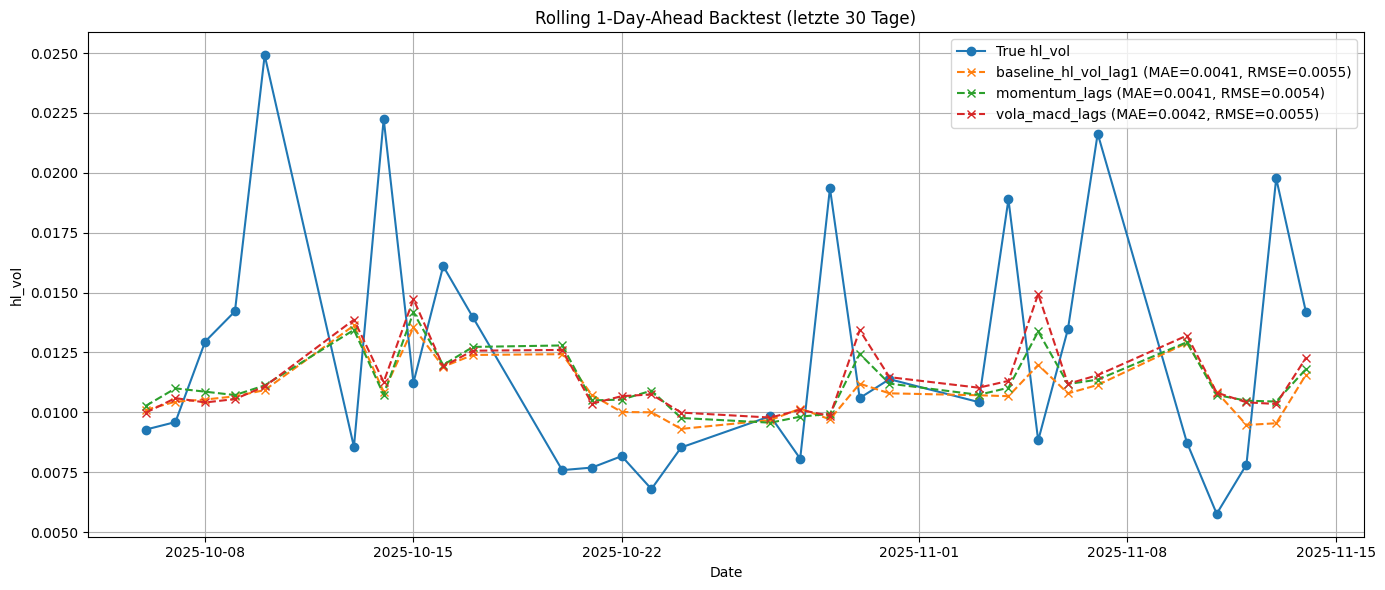

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_hl_vol_lag1,0.004050,0.005457,0.333333,-0.060273,0.115907
momentum_lags,0.004148,0.005424,0.266667,-0.088810,0.117241
vola_macd_lags,0.004244,0.005472,0.266667,-0.091363,0.093660



=== Forecast-Horizon: 3 Tag(e) voraus ===


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

baseline_hl_vol_lag1: MAE=0.004099, RMSE=0.005383, DirAcc=0.500, Pearson=-0.153, Spearman=-0.231


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

momentum_lags: MAE=0.004126, RMSE=0.005312, DirAcc=0.467, Pearson=-0.140, Spearman=-0.262


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

vola_macd_lags: MAE=0.004096, RMSE=0.005246, DirAcc=0.400, Pearson=-0.032, Spearman=-0.217


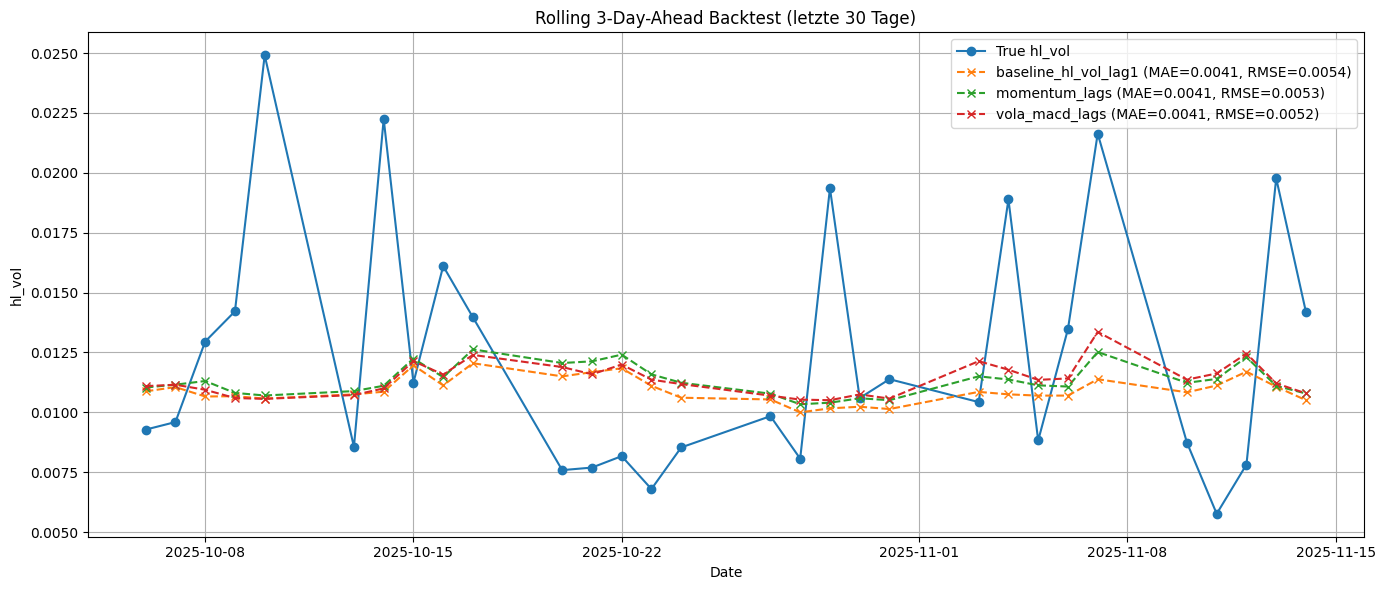

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_hl_vol_lag1,0.004099,0.005383,0.500000,-0.153485,-0.231146
momentum_lags,0.004126,0.005312,0.466667,-0.140410,-0.261846
vola_macd_lags,0.004096,0.005246,0.400000,-0.032246,-0.217353



=== Forecast-Horizon: 5 Tag(e) voraus ===


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

baseline_hl_vol_lag1: MAE=0.004066, RMSE=0.005409, DirAcc=0.433, Pearson=-0.255, Spearman=-0.346


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

momentum_lags: MAE=0.004146, RMSE=0.005407, DirAcc=0.400, Pearson=-0.377, Spearman=-0.380


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

vola_macd_lags: MAE=0.004084, RMSE=0.005354, DirAcc=0.333, Pearson=-0.282, Spearman=-0.345


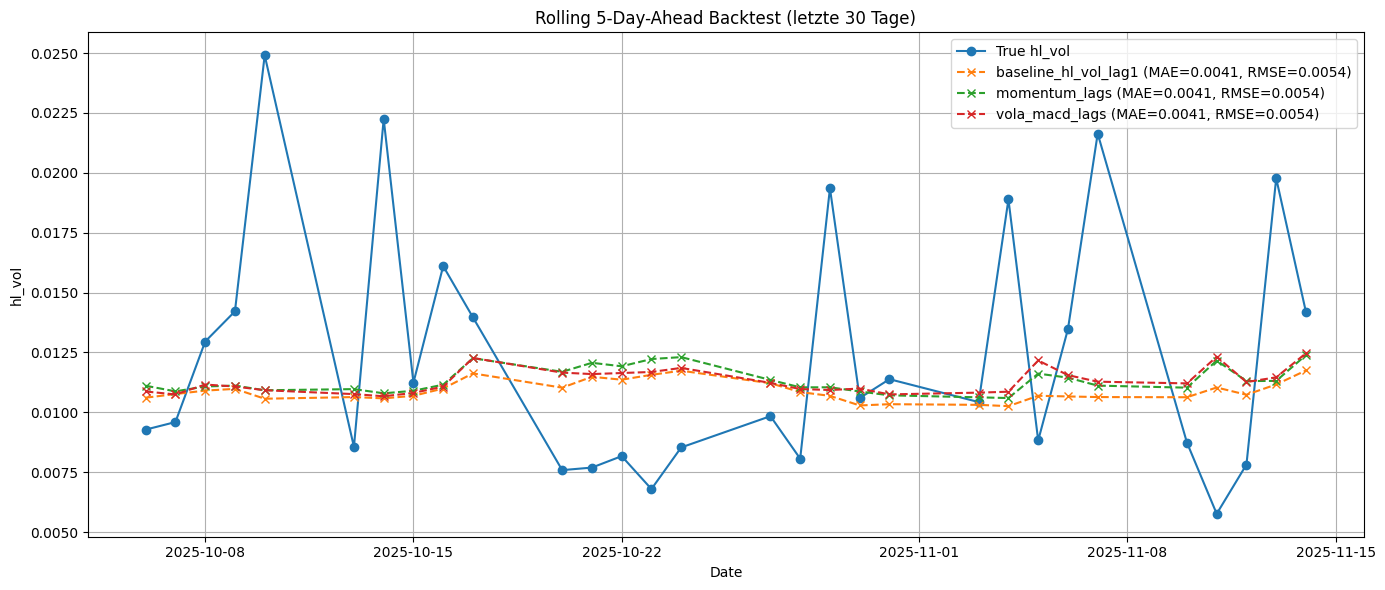

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_hl_vol_lag1,0.004066,0.005409,0.433333,-0.254872,-0.346385
momentum_lags,0.004146,0.005407,0.400000,-0.377356,-0.379755
vola_macd_lags,0.004084,0.005354,0.333333,-0.281571,-0.345495


In [8]:
# =========================
# Phase A – Experimente ausführen & auswerten
# =========================

for h in FORECAST_HORIZONS:
    print(f"\n=== Forecast-Horizon: {h} Tag(e) voraus ===")

    horizon_results = {}

    # Experimente laufen lassen
    for name, feat_cols in feature_sets.items():
        res = run_rolling_backtest(
            name=name,
            feature_cols=feat_cols,
            df_source=df,
            backtest_length=BACKTEST_LENGTH,
            forecast_horizon=h,
        )
        horizon_results[name] = res
        print(
            f"{name}: MAE={res['mae']:.6f}, RMSE={res['rmse']:.6f}, "
            f"DirAcc={res['directional_accuracy']:.3f}, "
            f"Pearson={res['pearson']:.3f}, Spearman={res['spearman']:.3f}"
        )

    # Plot vorbereiten (True + alle Varianten)
    plt.figure(figsize=(14, 6))

    # Referenz: True hl_vol
    first_key = next(iter(horizon_results))
    base_res = horizon_results[first_key]["results_df"]
    plt.plot(
        base_res["timestamp"],
        base_res["y_true"],
        marker="o",
        label="True hl_vol",
    )

    # Varianten einzeichnen
    for name, res in horizon_results.items():
        df_res = res["results_df"]
        plt.plot(
            df_res["timestamp"],
            df_res["y_pred"],
            linestyle="--",
            marker="x",
            label=f"{name} (MAE={res['mae']:.4f}, RMSE={res['rmse']:.4f})",
        )

    plt.title(f"Rolling {h}-Day-Ahead Backtest (letzte {BACKTEST_LENGTH} Tage)")
    plt.xlabel("Date")
    plt.ylabel("hl_vol")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Metrik-Tabelle
    metrics_df = pd.DataFrame(
        [
            {
                "Variant": name,
                "MAE": res["mae"],
                "RMSE": res["rmse"],
                "DirAcc": res["directional_accuracy"],
                "Pearson": res["pearson"],
                "Spearman": res["spearman"],
            }
            for name, res in horizon_results.items()
        ]
    ).set_index("Variant")

    display(metrics_df)


# Feature Engineering Part IV
Predicting the current target is very difficult. Since it is so random, the spikes cannot be predicted very well. We therefore adjust our target. We know try to predict RV_5, which is the realized volatility of the next 5 days. Therefore it should become a lot smoother and better to predict. 

In [9]:
# ============================================
# log(RV_5) Forecast – Setup & Model Loading
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline
from IPython.display import display

# Plot settings (optional)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True

# Chronos-2 laden (CPU)
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

# Konfiguration
BACKTEST_LENGTH = 40          # Rolling-Backtest-Fenster (Tage)
MAX_HISTORY_DAYS = 500        # Letzte N Tage verwenden (None = alles)
FORECAST_HORIZONS = [1, 3, 5] # 1-, 3- und 5-Tage-Vorhersage
TARGET_COL = "log_rv5"        # Name der Zielvariable


In [10]:
# ============================================
# Data Loading, log(RV_5) Construction & Features
# ============================================

# 1) CSV laden
df = pd.read_csv("UBS.csv")

# 2) Spaltennamen vereinheitlichen
df.columns = df.columns.str.lower()

# 3) timestamp parsen und sortieren
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.sort_values("timestamp", inplace=True)

# 4) Auf Business Days reindizieren
all_bdays = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="B",
)
df = df.set_index("timestamp").reindex(all_bdays)
df.index.name = "timestamp"
df = df.reset_index()

# 5) Forward-Fill für Kurs- und Indikator-Spalten
cols_price = [
    "open", "high", "low", "close", "volume",
    "sma", "ema", "rsi", "atr",
    "real lower band", "real middle band", "real upper band",
    "macd", "macd_signal", "macd_hist",
]
for col in cols_price:
    if col in df.columns:
        df[col] = df[col].ffill()

# 6) Tägliche log-Returns (close-to-close)
df["ret_cc"] = np.log(df["close"] / df["close"].shift(1))

# 7) Realized Volatility über 5 Tage (nicht annualisiert)
#    RV_5 = sqrt(sum_{i=1..5} ret_cc^2)
df["rv5"] = df["ret_cc"].rolling(5).apply(lambda x: np.sqrt((x**2).sum()), raw=True)

# 8) log(RV_5) als neues Target
df["log_rv5"] = np.log(df["rv5"])

# 9) Intraday High-Low-Volatilität (weiterhin als Feature nützlich)
df["hl_vol"] = np.log(df["high"] / df["low"])

# 10) Basis-Lags (1 Tag) für Vol und Indikatoren
df["hl_vol_lag1"] = df["hl_vol"].shift(1)
df["sma_lag1"] = df["sma"].shift(1)
df["ema_lag1"] = df["ema"].shift(1)
df["rsi_lag1"] = df["rsi"].shift(1)
df["atr_lag1"] = df["atr"].shift(1)
df["bb_lower_lag1"] = df["real lower band"].shift(1)
df["bb_mid_lag1"]   = df["real middle band"].shift(1)
df["bb_upper_lag1"] = df["real upper band"].shift(1)
df["macd_lag1"] = df["macd"].shift(1)
df["macd_hist_lag1"] = df["macd_hist"].shift(1)
df["macd_signal_lag1"] = df["macd_signal"].shift(1)

# 11) Bollinger-Band-Breite + Lag
df["bb_width"] = (df["real upper band"] - df["real lower band"]) / df["real middle band"]
df["bb_width_lag1"] = df["bb_width"].shift(1)

# 12) Volatility-Cluster-Features auf Basis von hl_vol
df["vol_ewm_5"]   = df["hl_vol"].ewm(span=5).mean()
df["vol_ewm_10"]  = df["hl_vol"].ewm(span=10).mean()
df["vol_std_5"]   = df["hl_vol"].rolling(5).std()
df["vol_std_10"]  = df["hl_vol"].rolling(10).std()

df["vol_ewm_5_lag1"]   = df["vol_ewm_5"].shift(1)
df["vol_ewm_10_lag1"]  = df["vol_ewm_10"].shift(1)
df["vol_std_5_lag1"]   = df["vol_std_5"].shift(1)
df["vol_std_10_lag1"]  = df["vol_std_10"].shift(1)

# 13) Optional: Lag des Targets als Feature
df["log_rv5_lag1"] = df["log_rv5"].shift(1)

# 14) Alle Zeilen verwerfen, bei denen Target oder zentrale Lags fehlen
lag_cols = [
    "hl_vol_lag1",
    "sma_lag1", "ema_lag1", "rsi_lag1", "atr_lag1",
    "bb_lower_lag1", "bb_mid_lag1", "bb_upper_lag1", "bb_width_lag1",
    "macd_lag1", "macd_hist_lag1", "macd_signal_lag1",
    "vol_ewm_5_lag1", "vol_ewm_10_lag1", "vol_std_5_lag1", "vol_std_10_lag1",
    "log_rv5_lag1",
]

df = df.dropna(subset=[TARGET_COL] + lag_cols).reset_index(drop=True)

# 15) Single-ID für Chronos
df["id"] = "UBS"

# 16) Optionale Begrenzung auf die letzten MAX_HISTORY_DAYS
if MAX_HISTORY_DAYS is not None and len(df) > MAX_HISTORY_DAYS:
    df = df.iloc[-MAX_HISTORY_DAYS:].reset_index(drop=True)

print(f"Datapoints after preprocessing: {len(df)}")
df[[ "timestamp", "close", "ret_cc", "rv5", "log_rv5" ]].head(10)


Datapoints after preprocessing: 500


,timestamp,close,ret_cc,rv5,log_rv5
0,2023-12-18,29.20,-0.002736,0.034565,-3.364910
1,2023-12-19,30.71,0.050420,0.061081,-2.795558
2,2023-12-20,30.33,-0.012451,0.060684,-2.802071
3,2023-12-21,30.67,0.011148,0.055520,-2.891006
4,2023-12-22,30.89,0.007148,0.053666,-2.924981
5,2023-12-25,30.89,0.000000,0.053596,-2.926282
6,2023-12-26,31.04,0.004844,0.018811,-3.973317
7,2023-12-27,31.19,0.004821,0.014902,-4.206272
8,2023-12-28,30.91,-0.009018,0.013383,-4.313744
9,2023-12-29,30.90,-0.000324,0.011320,-4.481226


In [12]:
# ============================================
# Feature Sets & Rolling Multi-Horizon Backtest for log(RV_5)
# ============================================

# Feature-Sets definieren
feature_sets = {
    # Einfacher Baseline-Ansatz:
    "baseline_log_rv5_lag1": ["log_rv5_lag1"],

    # Momentum-Features für Preis/Technik:
    "momentum_lags": [
        "log_rv5_lag1",
        "hl_vol_lag1",
        "rsi_lag1", "macd_lag1", "macd_signal_lag1", "macd_hist_lag1",
    ],

    # Volatility-Cluster + MACD:
    "vola_cluster_macd": [
        "log_rv5_lag1",
        "hl_vol_lag1",
        "atr_lag1", "bb_width_lag1",
        "vol_ewm_5_lag1", "vol_ewm_10_lag1",
        "vol_std_5_lag1", "vol_std_10_lag1",
        "macd_lag1", "macd_signal_lag1", "macd_hist_lag1",
    ],
}

def run_rolling_backtest_logrv5(
    name: str,
    feature_cols: list,
    df_source: pd.DataFrame,
    backtest_length: int = 40,
    forecast_horizon: int = 1,
    target_col: str = TARGET_COL,
):
    """
    Rolling h-step-ahead Backtest für log(RV_5).

    Für jeden Zieltag j:
    - Das Modell sieht Daten nur bis 'anchor = j - forecast_horizon'
    - Es wird 'forecast_horizon' Schritte in die Zukunft vorhergesagt
    - Der letzte Schritt wird mit dem tatsächlichen log(RV_5) am Zieltag j verglichen
    """

    cols_needed = [target_col] + feature_cols
    df_local = df_source.dropna(subset=cols_needed).copy()
    df_local = df_local.sort_values("timestamp").reset_index(drop=True)

    n = len(df_local)
    if backtest_length >= n:
        raise ValueError(f"backtest_length={backtest_length} ist zu groß für n={n}")

    target_indices = list(range(n - backtest_length, n))
    records = []

    for j in target_indices:
        anchor = j - forecast_horizon  # letzter Tag, den das Modell sehen darf

        if anchor < 0:
            continue

        context_df = df_local.iloc[: anchor + 1].copy()
        context_cols = ["id", "timestamp", target_col] + feature_cols
        context_df_chronos = context_df[context_cols].reset_index(drop=True)

        # Multi-Step Forecast
        pred_df = pipeline.predict_df(
            context_df_chronos,
            prediction_length=forecast_horizon,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="id",
            timestamp_column="timestamp",
            target=target_col,
        )

        # Vorhersage für Schritt 'forecast_horizon' (letzte Zeile)
        pred_row = pred_df.iloc[-1]
        ts_pred = pred_row["timestamp"]
        y_pred = pred_row["0.5"]
        q01 = pred_row["0.1"]
        q05 = pred_row["0.5"]
        q09 = pred_row["0.9"]

        # Tatsächlicher log(RV_5) am Zieltag j
        true_ts = df_local.loc[j, "timestamp"]
        true_val = df_local.loc[j, target_col]

        records.append(
            {
                "timestamp": true_ts,
                "y_true": true_val,
                "y_pred": y_pred,
                "q_0.1": q01,
                "q_0.5": q05,
                "q_0.9": q09,
            }
        )

    results_df = pd.DataFrame(records).sort_values("timestamp").reset_index(drop=True)

    # Metriken
    y_true = results_df["y_true"]
    y_pred = results_df["y_pred"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5

    # Richtung: steigende / fallende log(RV_5)
    true_diff = y_true.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    pred_diff = y_pred.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    directional_accuracy = (true_diff == pred_diff).mean()

    pearson_corr = y_true.corr(y_pred, method="pearson")
    spearman_corr = y_true.corr(y_pred, method="spearman")

    return {
        "results_df": results_df,
        "mae": mae,
        "rmse": rmse,
        "directional_accuracy": directional_accuracy,
        "pearson": pearson_corr,
        "spearman": spearman_corr,
    }



 Rolling 1-Day-Ahead Backtest for log(RV_5)


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

baseline_log_rv5_lag1: MAE=0.127470, RMSE=0.165699, DirAcc=0.475, Pearson=0.611, Spearman=0.652


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

momentum_lags: MAE=0.137828, RMSE=0.170808, DirAcc=0.525, Pearson=0.573, Spearman=0.590


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

vola_cluster_macd: MAE=0.144738, RMSE=0.176259, DirAcc=0.525, Pearson=0.593, Spearman=0.638


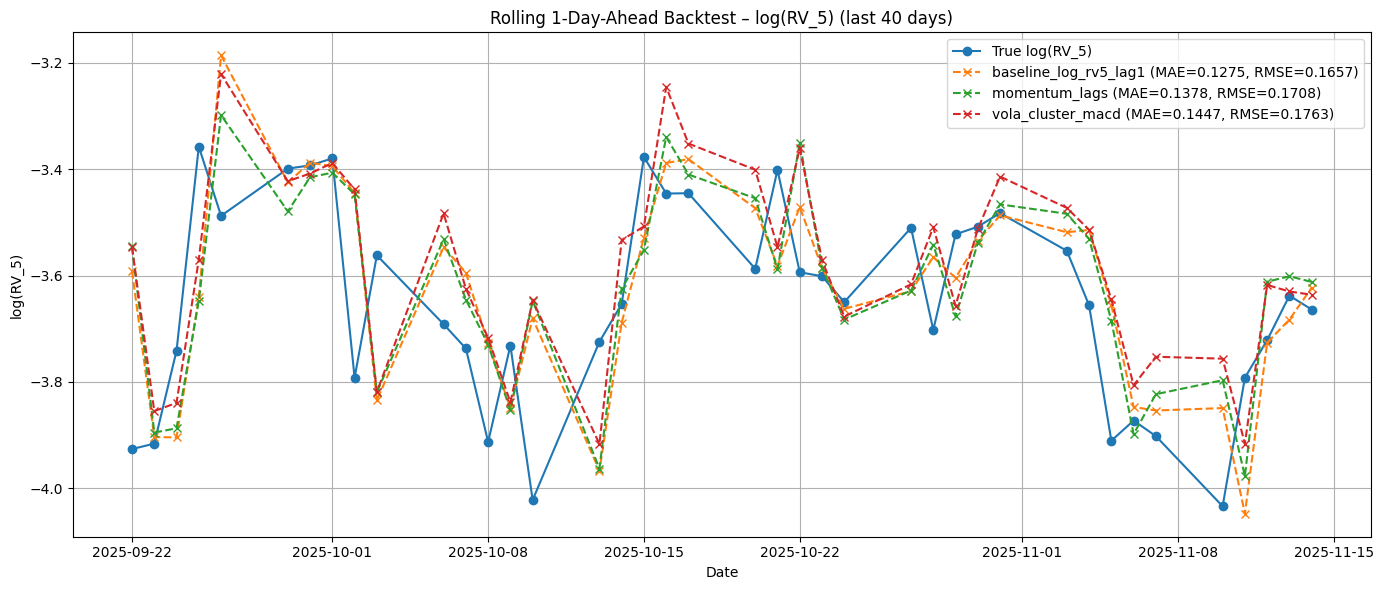

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_log_rv5_lag1,0.127470,0.165699,0.475,0.610708,0.651782
momentum_lags,0.137828,0.170808,0.525,0.572590,0.590244
vola_cluster_macd,0.144738,0.176259,0.525,0.592959,0.637523



 Rolling 3-Day-Ahead Backtest for log(RV_5)


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

baseline_log_rv5_lag1: MAE=0.154063, RMSE=0.199040, DirAcc=0.425, Pearson=0.318, Spearman=0.311


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

momentum_lags: MAE=0.175346, RMSE=0.216375, DirAcc=0.450, Pearson=0.263, Spearman=0.249


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

vola_cluster_macd: MAE=0.179852, RMSE=0.224400, DirAcc=0.450, Pearson=0.362, Spearman=0.327


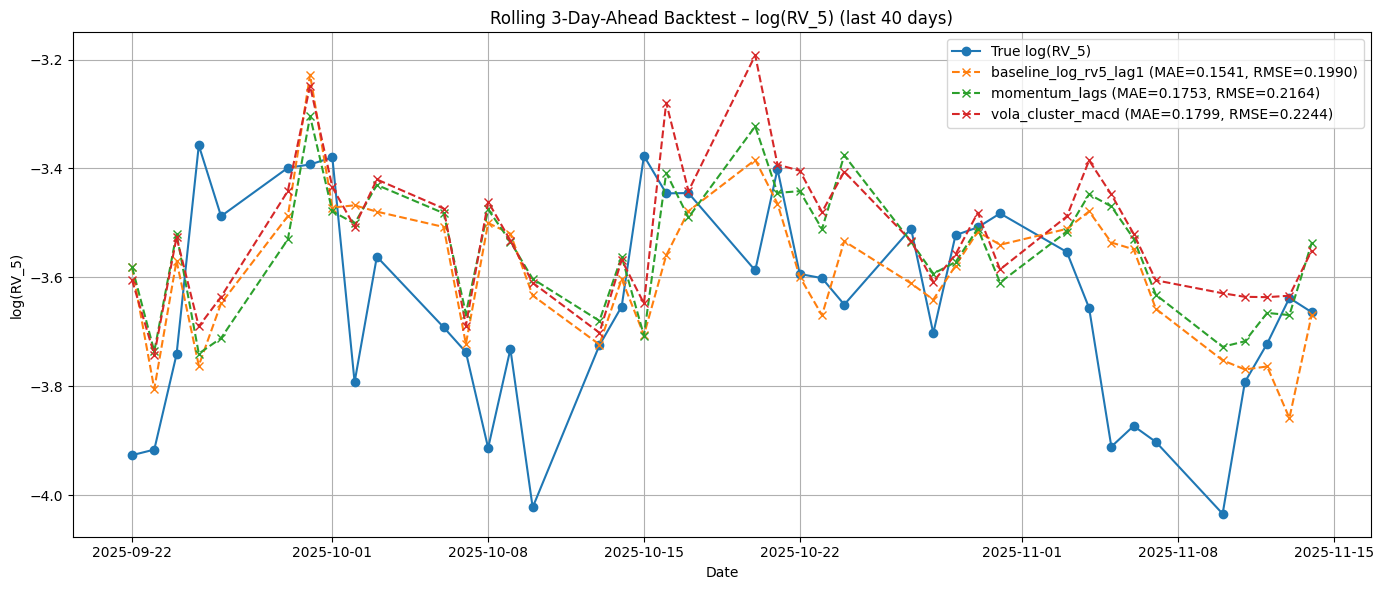

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_log_rv5_lag1,0.154063,0.199040,0.425,0.318219,0.311257
momentum_lags,0.175346,0.216375,0.450,0.263121,0.248968
vola_cluster_macd,0.179852,0.224400,0.450,0.361790,0.327392



 Rolling 5-Day-Ahead Backtest for log(RV_5)


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

baseline_log_rv5_lag1: MAE=0.169375, RMSE=0.217832, DirAcc=0.350, Pearson=0.035, Spearman=0.065


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

momentum_lags: MAE=0.206177, RMSE=0.250302, DirAcc=0.200, Pearson=-0.173, Spearman=-0.200


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

vola_cluster_macd: MAE=0.211185, RMSE=0.258160, DirAcc=0.350, Pearson=0.007, Spearman=0.009


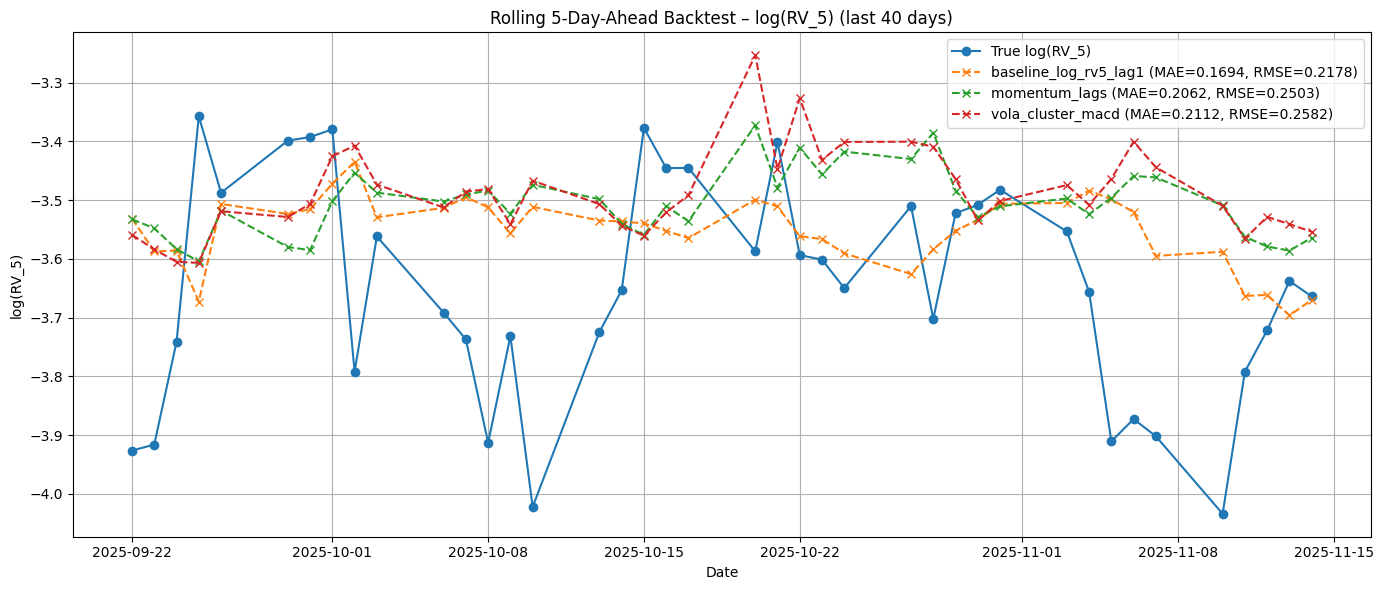

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_log_rv5_lag1,0.169375,0.217832,0.35,0.034540,0.065291
momentum_lags,0.206177,0.250302,0.20,-0.172651,-0.199625
vola_cluster_macd,0.211185,0.258160,0.35,0.006868,0.008630


In [13]:
# ============================================
# Experiments: log(RV_5) Forecast for H = 1,3,5
# ============================================

for h in FORECAST_HORIZONS:
    print(f"\n==============================")
    print(f" Rolling {h}-Day-Ahead Backtest for log(RV_5)")
    print(f"==============================")

    horizon_results = {}

    # Experimente für alle Feature-Sets
    for name, feat_cols in feature_sets.items():
        res = run_rolling_backtest_logrv5(
            name=name,
            feature_cols=feat_cols,
            df_source=df,
            backtest_length=BACKTEST_LENGTH,
            forecast_horizon=h,
            target_col=TARGET_COL,
        )
        horizon_results[name] = res
        print(
            f"{name}: MAE={res['mae']:.6f}, RMSE={res['rmse']:.6f}, "
            f"DirAcc={res['directional_accuracy']:.3f}, "
            f"Pearson={res['pearson']:.3f}, Spearman={res['spearman']:.3f}"
        )

    # Plot: True vs Predictions
    plt.figure(figsize=(14, 6))

    first_key = next(iter(horizon_results))
    base_res = horizon_results[first_key]["results_df"]

    # True log(RV_5)
    plt.plot(
        base_res["timestamp"],
        base_res["y_true"],
        marker="o",
        label="True log(RV_5)",
    )

    # Varianten
    for name, res in horizon_results.items():
        df_res = res["results_df"]
        plt.plot(
            df_res["timestamp"],
            df_res["y_pred"],
            linestyle="--",
            marker="x",
            label=f"{name} (MAE={res['mae']:.4f}, RMSE={res['rmse']:.4f})",
        )

    plt.title(f"Rolling {h}-Day-Ahead Backtest – log(RV_5) (last {BACKTEST_LENGTH} days)")
    plt.xlabel("Date")
    plt.ylabel("log(RV_5)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Metrik-Tabelle anzeigen
    metrics_df = pd.DataFrame(
        [
            {
                "Variant": name,
                "MAE": res["mae"],
                "RMSE": res["rmse"],
                "DirAcc": res["directional_accuracy"],
                "Pearson": res["pearson"],
                "Spearman": res["spearman"],
            }
            for name, res in horizon_results.items()
        ]
    ).set_index("Variant")

    display(metrics_df)


# Feature Engineering Part V 
We try to add macro-economic features
therefore target back to hl_vol


### Fetching Macro Data with yfinance and FRED

In [1]:
# ============================================
# Macro Data Fetch – Yahoo Finance + FRED
# ============================================

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt

from fredapi import Fred

In [2]:
# ---------- CONFIG ----------
FRED_API_KEY = "6e4c3c9e3f698a2828f2dd1f9079bcff"  

fred = Fred(api_key=FRED_API_KEY)

# Date range for macro data
START_DATE = "2016-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")

In [11]:
# ---------- 1) Market-based macro variables via Yahoo Finance ----------
# Tickers:
# ^VIX    = US Equity Volatility Index
# ^V2TX   = EURO STOXX 50 Volatility Index (VSTOXX)
# EURUSD=X = EUR/USD FX rate
# ^GSPC   = S&P 500 Index
# ^STOXX50E = EURO STOXX 50 Index
yahoo_tickers = {
    "VIX": "^VIX",
    #"VSTOXX": "V2TX", not found with yfinance
    "EURUSD": "EURUSD=X",
    "SP500": "^GSPC",
    "EUROSTOXX50": "^STOXX50E",
}

print("=== Fetching market-based macro data from Yahoo Finance ===")
yahoo_data = {}

for name, ticker in yahoo_tickers.items():
    print(f"\nDownloading {name} ({ticker}) ...")
    data = yf.download(ticker, start=START_DATE, end=END_DATE)
    # We keep only the 'Close' price as feature
    series = data["Close"].copy()
    series.name = name
    yahoo_data[name] = series
    print(series.head(), "\n")

# Combine all Yahoo series into one DataFrame
macro_yahoo_df = pd.concat(yahoo_data.values(), axis=1)

# Normalize index to date (drop intraday/timezone info)
macro_yahoo_df.index = pd.to_datetime(macro_yahoo_df.index).tz_localize(None)
macro_yahoo_df.index.name = "date"

print("\nCombined Yahoo macro data (head):")
print(macro_yahoo_df.head())
print("\nCombined Yahoo macro data (info):")
print(macro_yahoo_df.info())

C:\Users\Gil\AppData\Local\Temp\ipykernel_9640\3711844500.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed
C:\Users\Gil\AppData\Local\Temp\ipykernel_9640\3711844500.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed
C:\Users\Gil\AppData\Local\Temp\ipykernel_9640\3711844500.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed
C:\Users\Gil\AppData\Local\Temp\ipykernel_9640\3711844500.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=STA

=== Fetching market-based macro data from Yahoo Finance ===

Ticker           ^VIX
Date                 
2016-01-04  20.700001
2016-01-05  19.340000
2016-01-06  20.590000
2016-01-07  24.990000
2016-01-08  27.010000 


Ticker      EURUSD=X
Date                
2016-01-01  1.085906
2016-01-04  1.085399
2016-01-05  1.082755
2016-01-06  1.075199
2016-01-07  1.077900 


Ticker            ^GSPC
Date                   
2016-01-04  2012.660034
2016-01-05  2016.709961
2016-01-06  1990.260010
2016-01-07  1943.089966
2016-01-08  1922.030029 


Ticker        ^STOXX50E
Date                   
2016-01-04  3164.760010
2016-01-05  3178.010010
2016-01-06  3139.320068
2016-01-07  3084.679932
2016-01-08  3033.469971 


Combined Yahoo macro data (head):
Ticker           ^VIX  EURUSD=X        ^GSPC    ^STOXX50E
date                                                     
2016-01-01        NaN  1.085906          NaN          NaN
2016-01-04  20.700001  1.085399  2012.660034  3164.760010
2016-01-05  19.340000  1

In [12]:
# ---------- 2) Macro fundamentals via FRED ----------
# We'll fetch:
# - US CPI (CPIAUCSL)
# - Euro Area HICP (CP0000EZ19M086NEST)
# - US 10Y Treasury yield (DGS10)
# - Germany 10Y yield (IRLTLT01DEM156N)

fred_series = {
    "US_CPI": "CPIAUCSL",
    "EU_HICP": "CP0000EZ19M086NEST",
    "US_10Y_Yield": "DGS10",
    "DE_10Y_Yield": "IRLTLT01DEM156N",
}

fred_data = {}

print("\n=== Fetching macro fundamentals from FRED ===")
for name, series_id in fred_series.items():
    print(f"\nDownloading {name} ({series_id}) ...")
    # FRED returns a pandas Series with DatetimeIndex
    s = fred.get_series(series_id)
    s = s.rename(name)
    # Convert index to DatetimeIndex and filter date range
    s.index = pd.to_datetime(s.index)
    s = s.loc[(s.index >= START_DATE) & (s.index <= END_DATE)]
    fred_data[name] = s
    print(s.head(), "\n")

# Combine all FRED series
macro_fred_df = pd.concat(fred_data.values(), axis=1)
macro_fred_df.index = pd.to_datetime(macro_fred_df.index)
macro_fred_df.index.name = "date"

print("\nCombined FRED macro data (head):")
print(macro_fred_df.head())
print("\nCombined FRED macro data (info):")
print(macro_fred_df.info())


=== Fetching macro fundamentals from FRED ===

2016-01-01    237.652
2016-02-01    237.336
2016-03-01    238.080
2016-04-01    238.992
2016-05-01    239.557
Name: US_CPI, dtype: float64 


2016-01-01     98.56
2016-02-01     98.73
2016-03-01     99.96
2016-04-01    100.17
2016-05-01    100.59
Name: EU_HICP, dtype: float64 


2016-01-01     NaN
2016-01-04    2.24
2016-01-05    2.25
2016-01-06    2.18
2016-01-07    2.16
Name: US_10Y_Yield, dtype: float64 


2016-01-01    0.430500
2016-02-01    0.172857
2016-03-01    0.171429
2016-04-01    0.134286
2016-05-01    0.132857
Name: DE_10Y_Yield, dtype: float64 


Combined FRED macro data (head):
             US_CPI  EU_HICP  US_10Y_Yield  DE_10Y_Yield
date                                                    
2016-01-01  237.652    98.56           NaN        0.4305
2016-01-04      NaN      NaN          2.24           NaN
2016-01-05      NaN      NaN          2.25           NaN
2016-01-06      NaN      NaN          2.18           NaN
2016-01-07 

In [13]:
# ---------- 3) Combine Yahoo + FRED into single daily macro DataFrame ----------
# We reindex both to a common daily date range and forward-fill values.

full_date_range = pd.date_range(
    start=macro_yahoo_df.index.min().date(),
    end=macro_yahoo_df.index.max().date(),
    freq="B",
)
macro_yahoo_daily = macro_yahoo_df.reindex(full_date_range)
macro_fred_daily  = macro_fred_df.reindex(full_date_range)

# Forward-fill to propagate last known macro values
macro_yahoo_daily = macro_yahoo_daily.ffill()
macro_fred_daily  = macro_fred_daily.ffill()

# Merge horizontally
macro_df = pd.concat([macro_yahoo_daily, macro_fred_daily], axis=1)

macro_df.index.name = "date"

print("\n=== Final macro_df (daily, merged Yahoo + FRED) ===")
print(macro_df.head())
print("\nmacro_df info:")
print(macro_df.info())

# Save to CSV for later reuse / inspection
macro_df.to_csv("macro_features.csv", index=True)
print("\nSaved macro_features.csv with shape:", macro_df.shape)


=== Final macro_df (daily, merged Yahoo + FRED) ===
                 ^VIX  EURUSD=X  ...  US_10Y_Yield  DE_10Y_Yield
date                             ...                            
2016-01-01        NaN  1.085906  ...           NaN        0.4305
2016-01-04  20.700001  1.085399  ...          2.24        0.4305
2016-01-05  19.340000  1.082755  ...          2.25        0.4305
2016-01-06  20.590000  1.075199  ...          2.18        0.4305
2016-01-07  24.990000  1.077900  ...          2.16        0.4305

[5 rows x 8 columns]

macro_df info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2579 entries, 2016-01-01 to 2025-11-19
Freq: B
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ^VIX          2578 non-null   float64
 1   EURUSD=X      2579 non-null   float64
 2   ^GSPC         2578 non-null   float64
 3   ^STOXX50E     2578 non-null   float64
 4   US_CPI        2579 non-null   float64
 5   EU_HICP       25

### Merge our test UBS.CSV with macro_features.csv


In [14]:
import pandas as pd
import numpy as np

In [15]:
# 1) Load price/indicator data for UBS
ubs_df = pd.read_csv("UBS.csv")

# Ensure timestamp column exists and is datetime
# Adjust column name if your timestamp column is named differently
time_col_candidates = ["timestamp", "date", "Date"]
time_col = None
for c in time_col_candidates:
    if c in ubs_df.columns:
        time_col = c
        break

if time_col is None:
    raise ValueError("Could not find a timestamp/date column in UBS.csv")

ubs_df[time_col] = pd.to_datetime(ubs_df[time_col])
ubs_df = ubs_df.sort_values(time_col).reset_index(drop=True)

# Normalize to date (drop intraday)
ubs_df["date"] = ubs_df[time_col].dt.date

print("UBS data (head):")
print(ubs_df[[time_col, "date"]].head())

UBS data (head):
   timestamp        date
0 2015-01-12  2015-01-12
1 2015-01-13  2015-01-13
2 2015-01-14  2015-01-14
3 2015-01-15  2015-01-15
4 2015-01-16  2015-01-16


In [16]:
# 2) Load macro features
macro_df = pd.read_csv("macro_features.csv", parse_dates=["date"])
macro_df["date"] = macro_df["date"].dt.date
macro_df = macro_df.sort_values("date").reset_index(drop=True)

print("\nMacro data (head):")
print(macro_df.head())


Macro data (head):
         date       ^VIX  EURUSD=X  ...  EU_HICP  US_10Y_Yield  DE_10Y_Yield
0  2016-01-01        NaN  1.085906  ...    98.56           NaN        0.4305
1  2016-01-04  20.700001  1.085399  ...    98.56          2.24        0.4305
2  2016-01-05  19.340000  1.082755  ...    98.56          2.25        0.4305
3  2016-01-06  20.590000  1.075199  ...    98.56          2.18        0.4305
4  2016-01-07  24.990000  1.077900  ...    98.56          2.16        0.4305

[5 rows x 9 columns]


In [18]:
# 3) Merge UBS data with macro_df on 'date'
merged_df = pd.merge(
    ubs_df,
    macro_df,
    on="date",
    how="left",
)

print("\nMerged UBS + macro (head):")
print(merged_df.head())
print(merged_df.tail())
print("\nMerged shape:", merged_df.shape)


Merged UBS + macro (head):
   timestamp   open    high    low  ...  US_CPI  EU_HICP  US_10Y_Yield  DE_10Y_Yield
0 2015-01-12  16.42  16.490  16.31  ...     NaN      NaN           NaN           NaN
1 2015-01-13  16.65  16.825  16.46  ...     NaN      NaN           NaN           NaN
2 2015-01-14  16.54  16.580  16.26  ...     NaN      NaN           NaN           NaN
3 2015-01-15  16.90  16.980  16.17  ...     NaN      NaN           NaN           NaN
4 2015-01-16  16.02  16.380  16.01  ...     NaN      NaN           NaN           NaN

[5 rows x 25 columns]
      timestamp   open    high  ...  EU_HICP  US_10Y_Yield  DE_10Y_Yield
2724 2025-11-10  38.36  38.510  ...   129.63          4.13      2.617273
2725 2025-11-11  38.94  39.135  ...   129.63          4.13      2.617273
2726 2025-11-12  39.50  39.800  ...   129.63          4.08      2.617273
2727 2025-11-13  39.69  39.840  ...   129.63          4.11      2.617273
2728 2025-11-14  38.63  39.040  ...   129.63          4.14      2.617273



In [19]:
# 4) Optional: forward-fill missing macro values (if any dates lacked macro data)
macro_cols = [c for c in merged_df.columns if c not in ubs_df.columns]
merged_df[macro_cols] = merged_df[macro_cols].ffill()

In [20]:
# 5) Save merged dataset
merged_df.to_csv("UBS_with_macro.csv", index=False)
print("\nSaved UBS_with_macro.csv with shape:", merged_df.shape)


Saved UBS_with_macro.csv with shape: (2729, 25)


### Use the new UBS_with_macro csv with Chronos

#### Setup - Imports, Chronos-2, Config

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import Chronos2Pipeline
from IPython.display import display

# Plot Settings
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True

# load Chronos-2 (CPU)
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

# Config
BACKTEST_LENGTH = 40        # Amount of days for rolling backtest
MAX_HISTORY_DAYS = 500      # limit last n days
FORECAST_HORIZON = [1,3,5]        # 1-Day-Ahead Forecast for hl_vol
TARGET_COL = "log_rv5"       # Target


#### Data Loading & Feature Engineering (hl_vol + macro)

In [53]:
# 1) load Merged UBS + Macro-Daten
df = pd.read_csv("UBS_with_macro.csv")
print(df.tail())

       timestamp   open    high  ...  EU_HICP  US_10Y_Yield  DE_10Y_Yield
2724  2025-11-10  38.36  38.510  ...   129.63          4.13      2.617273
2725  2025-11-11  38.94  39.135  ...   129.63          4.13      2.617273
2726  2025-11-12  39.50  39.800  ...   129.63          4.08      2.617273
2727  2025-11-13  39.69  39.840  ...   129.63          4.11      2.617273
2728  2025-11-14  38.63  39.040  ...   129.63          4.14      2.617273

[5 rows x 25 columns]


In [54]:
# 2) Make columnnames lowercase
df.columns = df.columns.str.lower()
print(df.tail())

       timestamp   open    high  ...  eu_hicp  us_10y_yield  de_10y_yield
2724  2025-11-10  38.36  38.510  ...   129.63          4.13      2.617273
2725  2025-11-11  38.94  39.135  ...   129.63          4.13      2.617273
2726  2025-11-12  39.50  39.800  ...   129.63          4.08      2.617273
2727  2025-11-13  39.69  39.840  ...   129.63          4.11      2.617273
2728  2025-11-14  38.63  39.040  ...   129.63          4.14      2.617273

[5 rows x 25 columns]


In [55]:
# 3) Determine Timestamp
time_col_candidates = ["timestamp", "date", "datetime"]
time_col = None
for c in time_col_candidates:
    if c in df.columns:
        time_col = c
        break

if time_col is None:
    raise ValueError("Could not find a timestamp/date column in UBS_with_macro.csv")

df[time_col] = pd.to_datetime(df[time_col])
df = df.sort_values(time_col).reset_index(drop=True)

In [56]:
# 4) Set Business Day frequency (for Chronos)
all_bdays = pd.date_range(
    start=df[time_col].min().date(),
    end=df[time_col].max().date(),
    freq="B",
)
df = df.set_index(time_col).reindex(all_bdays)
df.index.name = "timestamp"
df = df.reset_index()

In [57]:
# 5) Forward-Fill 
for col in df.columns:
    if col not in ["timestamp"] and pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].ffill()

In [58]:
# 6) Close-to-Close Returns
if "close" not in df.columns:
    raise ValueError("Column 'close' must exist in UBS_with_macro.csv")

df["ret_cc"] = np.log(df["close"] / df["close"].shift(1))

In [ ]:
# 7) Calculate Target
df["rv5"] = df["ret_cc"].rolling(5).apply(lambda x: np.sqrt((x**2).sum()), raw=True)
df["log_rv5"] = np.log(df["rv5"])

In [61]:
# 8) Calculate hl_vol (as feature)
if "high" not in df.columns or "low" not in df.columns:
    raise ValueError("Columns 'high' and 'low' must exist in UBS_with_macro.csv")
df["hl_vol"] = np.log(df["high"] / df["low"])

In [62]:
# 9) Lags for log_rv5
df["log_rv5_lag1"] = df["log_rv5"].shift(1)
df["log_rv5_lag2"] = df["log_rv5"].shift(2)
df["log_rv5_lag5"] = df["log_rv5"].shift(5)

In [78]:
# 10) Technical features lag
def safe_shift(colname):
    if colname in df.columns:
        return df[colname].shift(1)
    else:
        return np.nan

df["open_lag1"] = df["open"].shift(1)
df["high_lag1"] = df["high"].shift(1)
df["close_lag1"] = df["close"].shift(1)
df["low_lag1"] = df["low"].shift(1)

df["hl_vol_lag1"] = df["hl_vol"].shift(1)

df["sma_lag1"] = safe_shift("sma")
df["ema_lag1"] = safe_shift("ema")
df["rsi_lag1"] = safe_shift("rsi")
df["atr_lag1"] = safe_shift("atr")

# Bollinger Bands

df["bb_width"] = (df["real upper band"] - df["real lower band"]) / df["real middle band"]
df["bb_width_lag1"] = df["bb_width"].shift(1)

df["macd_lag1"] = safe_shift("macd")
df["macd_signal_lag1"] = safe_shift("macd_signal")
df["macd_hist_lag1"] = safe_shift("macd_hist")

# Volatility-Cluster-Features (auf hl_vol)
df["vol_ewm_5"]   = df["hl_vol"].ewm(span=5).mean()
df["vol_ewm_10"]  = df["hl_vol"].ewm(span=10).mean()
df["vol_std_5"]   = df["hl_vol"].rolling(5).std()
df["vol_std_10"]  = df["hl_vol"].rolling(10).std()

df["vol_ewm_5_lag1"]   = df["vol_ewm_5"].shift(1)
df["vol_ewm_10_lag1"]  = df["vol_ewm_10"].shift(1)
df["vol_std_5_lag1"]   = df["vol_std_5"].shift(1)
df["vol_std_10_lag1"]  = df["vol_std_10"].shift(1)

print(df.columns)

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'sma', 'ema',
       'rsi', 'atr', 'real lower band', 'real middle band', 'real upper band',
       'macd', 'macd_hist', 'macd_signal', 'date', '^vix', 'eurusd=x', '^gspc',
       '^stoxx50e', 'us_cpi', 'eu_hicp', 'us_10y_yield', 'de_10y_yield',
       'ret_cc', 'rv5', 'log_rv5', 'hl_vol', 'log_rv5_lag1', 'log_rv5_lag2',
       'log_rv5_lag5', 'hl_vol_lag1', 'sma_lag1', 'ema_lag1', 'rsi_lag1',
       'atr_lag1', 'bb_width', 'bb_width_lag1', 'macd_lag1',
       'macd_signal_lag1', 'macd_hist_lag1', 'vol_ewm_5', 'vol_ewm_10',
       'vol_std_5', 'vol_std_10', 'vol_ewm_5_lag1', 'vol_ewm_10_lag1',
       'vol_std_5_lag1', 'vol_std_10_lag1', '^vix_lag1', 'eurusd=x_lag1',
       '^gspc_lag1', '^stoxx50e_lag1', 'us_cpi_lag1', 'eu_hicp_lag1',
       'us_10y_yield_lag1', 'de_10y_yield_lag1', '^gspc_ret', '^gspc_ret_lag1',
       'id', 'open_lag1', 'high_lag1', 'close_lag1', 'low_lag1'],
      dtype='object')


In [79]:
# 11) Identify Macro Columns
macro_base_cols= ['^vix', 'eurusd=x', '^gspc', '^stoxx50e', 'us_cpi', 'eu_hicp', 'us_10y_yield', 'de_10y_yield',]
macro_cols = [c for c in macro_base_cols if c in df.columns]

# Lags for macro cols

for col in macro_cols:
    df[f"{col}_lag1"] = df[col].shift(1)

# Index-Returns an lags
if "^gspc" in df.columns:
    df["^gspc_ret"]      = np.log(df["^gspc"] / df["^gspc"].shift(1))
    df["^gspc_ret_lag1"] = df["^gspc_ret"].shift(1)
if "eurostoxx50" in df.columns:
    df["^stoxx50e"]      = np.log(df["^stoxx50e"] / df["^stoxx50e"].shift(1))
    df["^stoxx50e_ret_lag1"] = df["^stoxx50e_ret"].shift(1)

print(df.columns)

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'sma', 'ema',
       'rsi', 'atr', 'real lower band', 'real middle band', 'real upper band',
       'macd', 'macd_hist', 'macd_signal', 'date', '^vix', 'eurusd=x', '^gspc',
       '^stoxx50e', 'us_cpi', 'eu_hicp', 'us_10y_yield', 'de_10y_yield',
       'ret_cc', 'rv5', 'log_rv5', 'hl_vol', 'log_rv5_lag1', 'log_rv5_lag2',
       'log_rv5_lag5', 'hl_vol_lag1', 'sma_lag1', 'ema_lag1', 'rsi_lag1',
       'atr_lag1', 'bb_width', 'bb_width_lag1', 'macd_lag1',
       'macd_signal_lag1', 'macd_hist_lag1', 'vol_ewm_5', 'vol_ewm_10',
       'vol_std_5', 'vol_std_10', 'vol_ewm_5_lag1', 'vol_ewm_10_lag1',
       'vol_std_5_lag1', 'vol_std_10_lag1', '^vix_lag1', 'eurusd=x_lag1',
       '^gspc_lag1', '^stoxx50e_lag1', 'us_cpi_lag1', 'eu_hicp_lag1',
       'us_10y_yield_lag1', 'de_10y_yield_lag1', '^gspc_ret', '^gspc_ret_lag1',
       'id', 'open_lag1', 'high_lag1', 'close_lag1', 'low_lag1'],
      dtype='object')


In [80]:
# 12) Drop Rows with missing target or important lags
core_lags = ["log_rv5_lag1", "log_rv5_lag2", "log_rv5_lag5"]
df = df.dropna(subset=[TARGET_COL] + core_lags).reset_index(drop=True)

In [81]:
# 13) Single ID
df["id"] = "UBS"

In [ ]:
print(f"Data points after preprocessing: {len(df)}")
print("Columns (sample):")
print(df.columns.tolist()[:40])
print("\nSample rows:")
print(df[["timestamp", "log_rv5", "log_rv5_lag1", "log_rv5_lag2", "log_rv5_lag5"]].head())


Data points after preprocessing: 2820
Columns (sample):
['timestamp', 'open', 'high', 'low', 'close', 'volume', 'sma', 'ema', 'rsi', 'atr', 'real lower band', 'real middle band', 'real upper band', 'macd', 'macd_hist', 'macd_signal', 'date', '^vix', 'eurusd=x', '^gspc', '^stoxx50e', 'us_cpi', 'eu_hicp', 'us_10y_yield', 'de_10y_yield', 'ret_cc', 'rv5', 'log_rv5', 'hl_vol', 'log_rv5_lag1', 'log_rv5_lag2', 'log_rv5_lag5', 'hl_vol_lag1', 'sma_lag1', 'ema_lag1', 'rsi_lag1', 'atr_lag1', 'bb_width', 'bb_width_lag1', 'macd_lag1']

Sample rows:
   timestamp   log_rv5  log_rv5_lag1  log_rv5_lag2  log_rv5_lag5
0 2015-01-26 -3.301795     -3.311885     -3.209459     -3.751729
1 2015-01-27 -3.465159     -3.301795     -3.311885     -3.569176
2 2015-01-28 -3.136055     -3.465159     -3.301795     -3.484784
3 2015-01-29 -3.281324     -3.136055     -3.465159     -3.209459
4 2015-01-30 -3.257345     -3.281324     -3.136055     -3.311885
Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'sma',

#### Feature Sets, Rolling Backtest (1-Day Ahead hl_vol), Plots + Metrics

In [73]:
# 1) Define Feature-Sets

macro_lag_cols = [f"{c}_lag1" for c in macro_cols if f"{c}_lag1" in df.columns]
extra_lags = []

if "^gspc_ret_lag1" in df.columns:
    extra_lags.append("^gspc_ret_lag1")
if "^stoxx50e_ret_lag1" in df.columns:
    extra_lags.append("^stoxx50e_ret_lag1")

feature_sets = {
    # Baseline: only lagged volatility
    "baseline_rv_lags": [
        "log_rv5_lag1", "log_rv5_lag2", "log_rv5_lag5",
    ],
    
    # Only technical indicators
    "technical_only": [
        "log_rv5_lag1", "log_rv5_lag2", "log_rv5_lag5",
        "hl_vol_lag1",
        "sma_lag1", "ema_lag1", "rsi_lag1", "atr_lag1",
        "bb_width_lag1",
        "macd_lag1", "macd_signal_lag1", "macd_hist_lag1",
        "vol_ewm_5_lag1", "vol_ewm_10_lag1",
        "vol_std_5_lag1", "vol_std_10_lag1",
    ],
    
    # Only macro indicators + lagged volatility
    "macro_only": (
        ["log_rv5_lag1", "log_rv5_lag2", "log_rv5_lag5"] +
        macro_lag_cols +
        extra_lags
    ),

    # D) Full Model – Technik + Makro
    "full_model": (
        ["log_rv5_lag1", "log_rv5_lag2", "log_rv5_lag5", "hl_vol_lag1","sma_lag1", "ema_lag1", "rsi_lag1", "atr_lag1",
            "bb_width_lag1",
            "macd_lag1", "macd_signal_lag1", "macd_hist_lag1",
            "vol_ewm_5_lag1", "vol_ewm_10_lag1",
            "vol_std_5_lag1", "vol_std_10_lag1",
        ] +
        macro_lag_cols +
        extra_lags)
}


# Only keep columns that really exist
for name, cols in feature_sets.items():
    feature_sets[name] = [c for c in cols if c in df.columns]



In [84]:
# 2) Define Experiment function
def run_rolling_backtest_hlvol(
    name: str,
    feature_cols: list,
    df_source: pd.DataFrame,
    backtest_length: int = BACKTEST_LENGTH,
    forecast_horizon: int = FORECAST_HORIZON,
    target_col: str = TARGET_COL,
):
    cols_needed = [target_col] + feature_cols
    df_local = df_source.dropna(subset=cols_needed).copy()
    df_local = df_local.sort_values("timestamp").reset_index(drop=True)

    n = len(df_local)
    if backtest_length >= n:
        raise ValueError(f"backtest_length={backtest_length} ist zu groß für n={n}")
    
    target_indices = list(range(n - backtest_length, n))
    records = []

    for j in target_indices:
        anchor = j - forecast_horizon
        if anchor < 0:
            continue

        context_df = df_local.iloc[: anchor + 1].copy()
        context_cols = ["id", "timestamp", target_col] + feature_cols
        context_df_chronos = context_df[context_cols].reset_index(drop=True)

        # Multi-Step Forecast (forecast_horizon = 1 → 1-Day-Ahead)
        pred_df = pipeline.predict_df(
            context_df_chronos,
            prediction_length=forecast_horizon,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="id",
            timestamp_column="timestamp",
            target=target_col,
        )

        # Prediction for step 'forecast_horizon' (last row)
        pred_row = pred_df.iloc[-1]
        ts_pred = pred_row["timestamp"]
        y_pred = pred_row["0.5"]
        q01 = pred_row["0.1"]
        q05 = pred_row["0.5"]
        q09 = pred_row["0.9"]

        # real hl_vol on target day j
        true_ts = df_local.loc[j, "timestamp"]
        true_val = df_local.loc[j, target_col]

        records.append(
            {
                "timestamp": true_ts,
                "y_true": true_val,
                "y_pred": y_pred,
                "q_0.1": q01,
                "q_0.5": q05,
                "q_0.9": q09,
            }
        )

    results_df = pd.DataFrame(records).sort_values("timestamp").reset_index(drop=True)

    # Metrics
    y_true = results_df["y_true"]
    y_pred = results_df["y_pred"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5

    # Directional Accuracy (Up / Down of hl_vol)
    true_diff = y_true.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    pred_diff = y_pred.diff().apply(lambda x: 1 if x > 0 else 0 if x < 0 else np.nan)
    directional_accuracy = (true_diff == pred_diff).mean()

    pearson_corr = y_true.corr(y_pred, method="pearson")
    spearman_corr = y_true.corr(y_pred, method="spearman")

    return {
        "results_df": results_df,
        "mae": mae,
        "rmse": rmse,
        "directional_accuracy": directional_accuracy,
        "pearson": pearson_corr,
        "spearman": spearman_corr,
    }


In [75]:
# 3) Run Experiments

for h in FORECAST_HORIZON:
    print(f" Rolling {h}-Day-Ahead Backtest – log(RV5)")

    horizon_results = {}

    for name, feat_cols in feature_sets.items():
        print(f"\n=== Running experiment: {name} ===")
        print("Features:", feat_cols)

        res = run_rolling_backtest_hlvol(
            name=name,
            feature_cols=feat_cols,
            df_source=df,
            backtest_length=BACKTEST_LENGTH,
            forecast_horizon=h,
            target_col=TARGET_COL,
        )
        horizon_results[name] = res

        print(
            f"{name}: MAE={res['mae']:.6f}, RMSE={res['rmse']:.6f}, "
            f"DirAcc={res['directional_accuracy']:.3f}, "
            f"Pearson={res['pearson']:.3f}, Spearman={res['spearman']:.3f}"
        )

 Rolling 1-Day-Ahead Backtest – log(RV5)

=== Running experiment: baseline_rv_lags ===
Features: ['log_rv5_lag1', 'log_rv5_lag2', 'log_rv5_lag5']


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

baseline_rv_lags: MAE=0.119193, RMSE=0.149945, DirAcc=0.450, Pearson=0.638, Spearman=0.678

=== Running experiment: technical_only ===
Features: ['log_rv5_lag1', 'log_rv5_lag2', 'log_rv5_lag5', 'hl_vol_lag1', 'sma_lag1', 'ema_lag1', 'rsi_lag1', 'atr_lag1', 'bb_width_lag1', 'macd_lag1', 'macd_signal_lag1', 'macd_hist_lag1', 'vol_ewm_5_lag1', 'vol_ewm_10_lag1', 'vol_std_5_lag1', 'vol_std_10_lag1']


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

technical_only: MAE=0.142139, RMSE=0.169091, DirAcc=0.425, Pearson=0.588, Spearman=0.606

=== Running experiment: macro_only ===
Features: ['log_rv5_lag1', 'log_rv5_lag2', 'log_rv5_lag5', '^vix_lag1', 'eurusd=x_lag1', '^gspc_lag1', '^stoxx50e_lag1', 'us_cpi_lag1', 'eu_hicp_lag1', 'us_10y_yield_lag1', 'de_10y_yield_lag1', '^gspc_ret_lag1']


...

technical_only: MAE=0.237623, RMSE=0.279703, DirAcc=0.275, Pearson=-0.203, Spearman=-0.175

=== Running experiment: macro_only ===
Features: ['log_rv5_lag1', 'log_rv5_lag2', 'log_rv5_lag5', '^vix_lag1', 'eurusd=x_lag1', '^gspc_lag1', '^stoxx50e_lag1', 'us_cpi_lag1', 'eu_hicp_lag1', 'us_10y_yield_lag1', 'de_10y_yield_lag1', '^gspc_ret_lag1']


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

macro_only: MAE=0.192558, RMSE=0.232452, DirAcc=0.250, Pearson=-0.231, Spearman=-0.227

=== Running experiment: full_model ===
Features: ['log_rv5_lag1', 'log_rv5_lag2', 'log_rv5_lag5', 'hl_vol_lag1', 'sma_lag1', 'ema_lag1', 'rsi_lag1', 'atr_lag1', 'bb_width_lag1', 'macd_lag1', 'macd_signal_lag1', 'macd_hist_lag1', 'vol_ewm_5_lag1', 'vol_ewm_10_lag1', 'vol_std_5_lag1', 'vol_std_10_lag1', '^vix_lag1', 'eurusd=x_lag1', '^gspc_lag1', '^stoxx50e_lag1', 'us_cpi_lag1', 'eu_hicp_lag1', 'us_10y_yield_lag1', 'de_10y_yield_lag1', '^gspc_ret_lag1']


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

full_model: MAE=0.215957, RMSE=0.256084, DirAcc=0.275, Pearson=-0.247, Spearman=-0.244


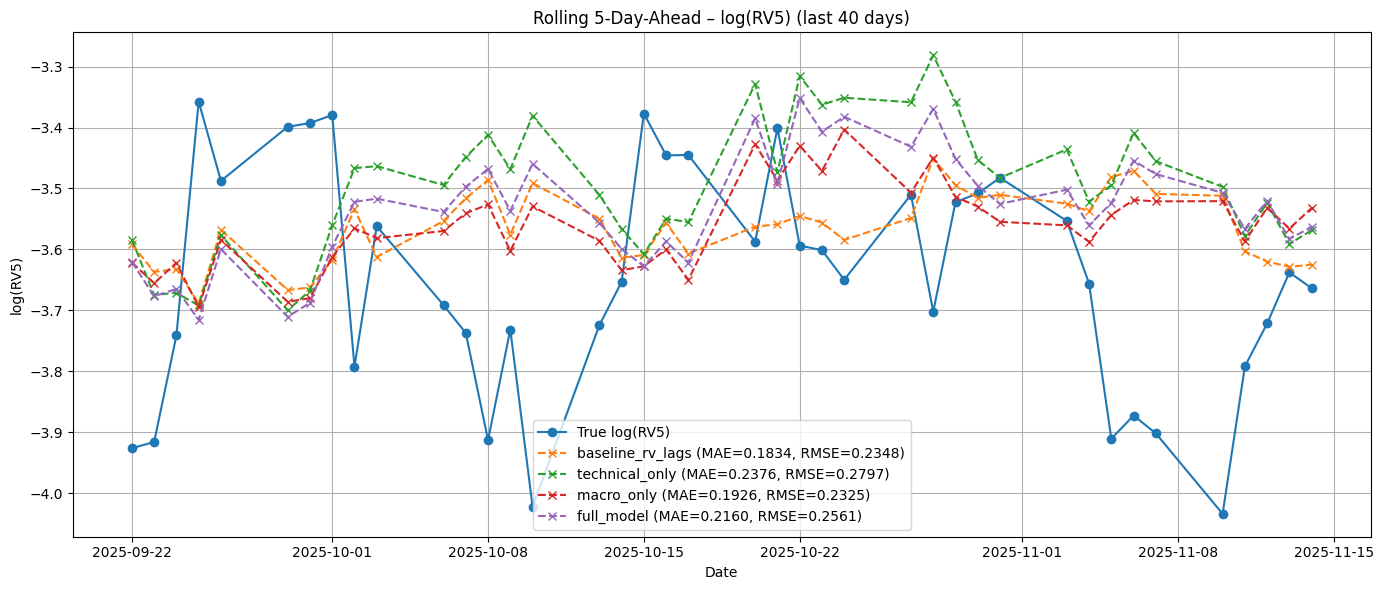

In [76]:
# 4) Plot results
plt.figure(figsize=(14, 6))

# True hl_vol from a random experient (all have same y_true)
first_key = next(iter(horizon_results))
base_res = horizon_results[first_key]["results_df"]

plt.plot(
    base_res["timestamp"],
    base_res["y_true"],
    marker="o",
    label="True log(RV5)",
)

for name, res in horizon_results.items():
    df_res = res["results_df"]
    plt.plot(
        df_res["timestamp"],
        df_res["y_pred"],
        linestyle="--",
        marker="x",
        label=f"{name} (MAE={res['mae']:.4f}, RMSE={res['rmse']:.4f})",
    )

plt.title(f"Rolling {h}-Day-Ahead – log(RV5) (last {BACKTEST_LENGTH} days)")
plt.xlabel("Date")
plt.ylabel("log(RV5)")
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
# 5) Metrics Table
metrics_df = pd.DataFrame(
    [
        {
            "Variant": name,
            "MAE": res["mae"],
            "RMSE": res["rmse"],
            "DirAcc": res["directional_accuracy"],
            "Pearson": res["pearson"],
            "Spearman": res["spearman"],
        }
        for name, res in horizon_results.items()
    ]
).set_index("Variant")

display(metrics_df)

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_rv_lags,0.183408,0.234784,0.350,-0.436011,-0.388180
technical_only,0.237623,0.279703,0.275,-0.203249,-0.175047
macro_only,0.192558,0.232452,0.250,-0.230905,-0.226642
full_model,0.215957,0.256084,0.275,-0.247391,-0.244278


In [85]:
# 1) Define Feature-Sets

macro_lag_cols = [f"{c}_lag1" for c in macro_cols if f"{c}_lag1" in df.columns]
extra_lags = []

if "^gspc_ret_lag1" in df.columns:
    extra_lags.append("^gspc_ret_lag1")
if "^stoxx50e_ret_lag1" in df.columns:
    extra_lags.append("^stoxx50e_ret_lag1")

feature_sets = {
    # Baseline: only lagged ohlc
    "baseline_ohlc_lags": [
        "open_lag1", "close_lag1", "high_lag1", "low_lag1",
    ],
    
    # Only technical indicators + lagged ohlcv
    "technical_only": [
        "open_lag1", "close_lag1", "high_lag1", "low_lag1",
        "sma_lag1", "ema_lag1", "rsi_lag1", "atr_lag1",
        "bb_width_lag1",
        "macd_lag1", "macd_signal_lag1", "macd_hist_lag1",
        "vol_ewm_5_lag1", "vol_ewm_10_lag1",
        "vol_std_5_lag1", "vol_std_10_lag1",
    ],
    
    # Only macro indicators + lagged ohclv
    "macro_only": (
        ["open_lag1", "close_lag1", "high_lag1", "low_lag1",] +
        macro_lag_cols +
        extra_lags
    ),

    # D) Full Model – Technik + Makro
    "full_model": (
        [   "open_lag1", "close_lag1", "high_lag1", "low_lag1","sma_lag1", "ema_lag1", "rsi_lag1", "atr_lag1",
            "bb_width_lag1",
            "macd_lag1", "macd_signal_lag1", "macd_hist_lag1",
            "vol_ewm_5_lag1", "vol_ewm_10_lag1",
            "vol_std_5_lag1", "vol_std_10_lag1",
        ] +
        macro_lag_cols +
        extra_lags)
}


# Only keep columns that really exist
for name, cols in feature_sets.items():
    feature_sets[name] = [c for c in cols if c in df.columns]



In [89]:
# 3) Run Experiments

for h in FORECAST_HORIZON:
    print(f" Rolling {h}-Day-Ahead Backtest – log(RV5)")

    horizon_results = {}

    for name, feat_cols in feature_sets.items():
        print(f"\n=== Running experiment: {name} ===")
        print("Features:", feat_cols)

        res = run_rolling_backtest_hlvol(
            name=name,
            feature_cols=feat_cols,
            df_source=df,
            backtest_length=BACKTEST_LENGTH,
            forecast_horizon=h,
            target_col=TARGET_COL,
        )
        horizon_results[name] = res

        print(
            f"{name}: MAE={res['mae']:.6f}, RMSE={res['rmse']:.6f}, "
            f"DirAcc={res['directional_accuracy']:.3f}, "
            f"Pearson={res['pearson']:.3f}, Spearman={res['spearman']:.3f}"
        )

 Rolling 1-Day-Ahead Backtest – log(RV5)

=== Running experiment: baseline_ohlc_lags ===
Features: ['open_lag1', 'close_lag1', 'high_lag1', 'low_lag1']


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

baseline_ohlc_lags: MAE=0.130326, RMSE=0.162570, DirAcc=0.425, Pearson=0.585, Spearman=0.603

=== Running experiment: technical_only ===
Features: ['open_lag1', 'close_lag1', 'high_lag1', 'low_lag1', 'sma_lag1', 'ema_lag1', 'rsi_lag1', 'atr_lag1', 'bb_width_lag1', 'macd_lag1', 'macd_signal_lag1', 'macd_hist_lag1', 'vol_ewm_5_lag1', 'vol_ewm_10_lag1', 'vol_std_5_lag1', 'vol_std_10_lag1']


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

technical_only: MAE=0.138597, RMSE=0.168243, DirAcc=0.375, Pearson=0.565, Spearman=0.590

=== Running experiment: macro_only ===
Features: ['open_lag1', 'close_lag1', 'high_lag1', 'low_lag1', '^vix_lag1', 'eurusd=x_lag1', '^gspc_lag1', '^stoxx50e_lag1', 'us_cpi_lag1', 'eu_hicp_lag1', 'us_10y_yield_lag1', 'de_10y_yield_lag1', '^gspc_ret_lag1']


...

technical_only: MAE=0.220326, RMSE=0.265668, DirAcc=0.225, Pearson=-0.269, Spearman=-0.261

=== Running experiment: macro_only ===
Features: ['open_lag1', 'close_lag1', 'high_lag1', 'low_lag1', '^vix_lag1', 'eurusd=x_lag1', '^gspc_lag1', '^stoxx50e_lag1', 'us_cpi_lag1', 'eu_hicp_lag1', 'us_10y_yield_lag1', 'de_10y_yield_lag1', '^gspc_ret_lag1']


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

macro_only: MAE=0.190395, RMSE=0.234272, DirAcc=0.225, Pearson=-0.293, Spearman=-0.279

=== Running experiment: full_model ===
Features: ['open_lag1', 'close_lag1', 'high_lag1', 'low_lag1', 'sma_lag1', 'ema_lag1', 'rsi_lag1', 'atr_lag1', 'bb_width_lag1', 'macd_lag1', 'macd_signal_lag1', 'macd_hist_lag1', 'vol_ewm_5_lag1', 'vol_ewm_10_lag1', 'vol_std_5_lag1', 'vol_std_10_lag1', '^vix_lag1', 'eurusd=x_lag1', '^gspc_lag1', '^stoxx50e_lag1', 'us_cpi_lag1', 'eu_hicp_lag1', 'us_10y_yield_lag1', 'de_10y_yield_lag1', '^gspc_ret_lag1']


c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\chronos-2\env\Lib\site-packages\torch\utils\data\datal

full_model: MAE=0.213967, RMSE=0.257323, DirAcc=0.250, Pearson=-0.281, Spearman=-0.271


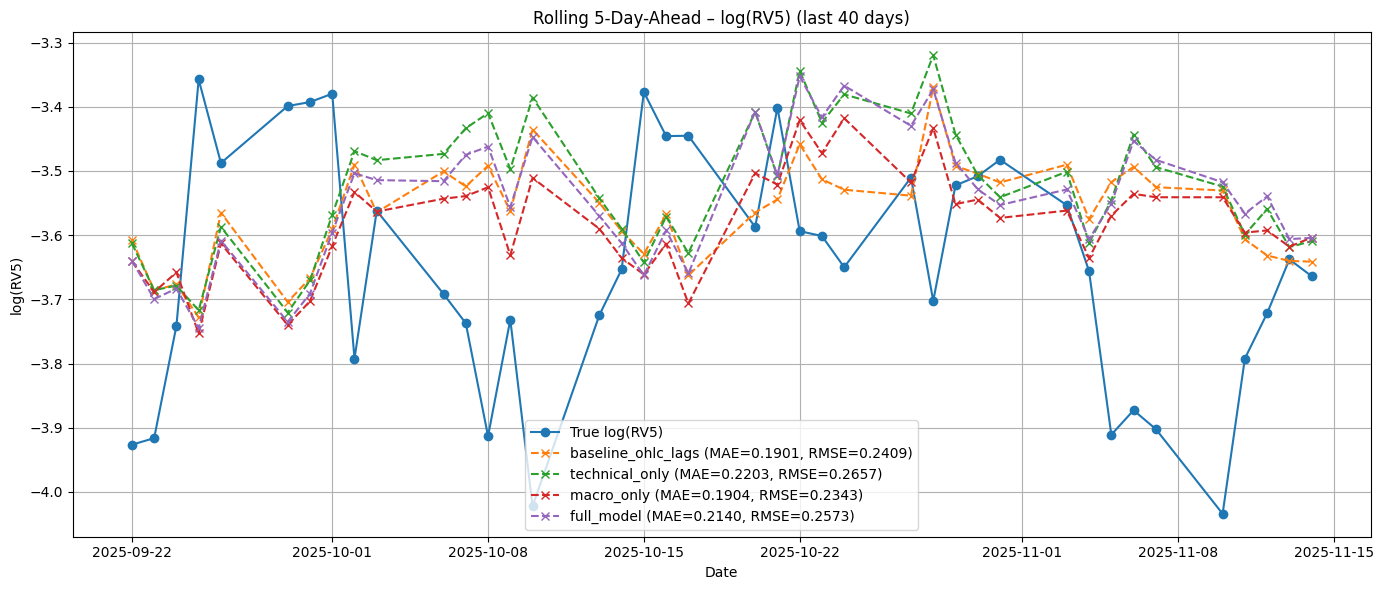

In [90]:
# 4) Plot results
plt.figure(figsize=(14, 6))

# True hl_vol from a random experient (all have same y_true)
first_key = next(iter(horizon_results))
base_res = horizon_results[first_key]["results_df"]

plt.plot(
    base_res["timestamp"],
    base_res["y_true"],
    marker="o",
    label="True log(RV5)",
)

for name, res in horizon_results.items():
    df_res = res["results_df"]
    plt.plot(
        df_res["timestamp"],
        df_res["y_pred"],
        linestyle="--",
        marker="x",
        label=f"{name} (MAE={res['mae']:.4f}, RMSE={res['rmse']:.4f})",
    )

plt.title(f"Rolling {h}-Day-Ahead – log(RV5) (last {BACKTEST_LENGTH} days)")
plt.xlabel("Date")
plt.ylabel("log(RV5)")
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
# 5) Metrics Table
metrics_df = pd.DataFrame(
    [
        {
            "Variant": name,
            "MAE": res["mae"],
            "RMSE": res["rmse"],
            "DirAcc": res["directional_accuracy"],
            "Pearson": res["pearson"],
            "Spearman": res["spearman"],
        }
        for name, res in horizon_results.items()
    ]
).set_index("Variant")

display(metrics_df)

,MAE,RMSE,DirAcc,Pearson,Spearman
Variant,,,,,
baseline_ohlc_lags,0.190078,0.240931,0.300,-0.324671,-0.298499
technical_only,0.220326,0.265668,0.225,-0.269006,-0.260600
macro_only,0.190395,0.234272,0.225,-0.292656,-0.278987
full_model,0.213967,0.257323,0.250,-0.281048,-0.271107
